# AI Productivity: Exploratory Data Analysis


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.colors as mcolors
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, r2_score,
    classification_report, roc_auc_score,
)
from xgboost import XGBRegressor, XGBClassifier
import shap
import statsmodels.formula.api as smf

from scipy.optimize import minimize_scalar
from scipy.interpolate import interp1d

from scripts.preprocess import load_preprocessed_data

import warnings
warnings.filterwarnings("ignore")

C1  = "#456185"        
C2  = "#81A0BC"       
C3  = "#284544"         
C4  = '#A8C5DA'  
C5  = "#ADA9B0"   
C6  = "#7A2008"   
C7  = "#CFB58B"         
C8  = '#F8F4F0'       
CDARK  = '#1F2937' 
CGREY  = '#CCCCCC' 

sns.set_style('white')
plt.rcParams.update({
    'font.family':        'sans-serif',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          False,
    'figure.facecolor':   'white',
    'axes.facecolor':     'white',
})

PRIMARY = "#355C73"
RISK    = "#B5614C"
ACCENT  = "#5F7F76"

/Users/tabbba/Desktop/Machine-Learning/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Initial Inspection

In [2]:
df = pd.read_csv('data/ai_productivity_dataset_final.csv')
print(f'Rows: {df.shape[0]:,}   Columns: {df.shape[1]}')
df.head()

Rows: 3,248   Columns: 34


,task_id,client,project_id,client_tier,team,task_type,seniority,task_complexity_score,brief_quality_score,deadline_pressure,...,revenue,cost,profit,created_by,updated_at,task_status,workflow_stage,jira_ticket,legacy_ai_flag,content_version
0,T00000,Client_F,P038,mid,Content,report,junior,2,3.0,high,...,498.11,346.17,151.94,user_096,2025-11-28,review,finalized,JIRA-49014,true,v1
1,T00001,Client_H,P028,low,Paid Media,release,junior,1,2.0,medium,...,847.01,343.18,503.83,user_058,2026-01-26,delivered,client_review,JIRA-84793,false,v1
2,T00002,Client_D,P009,low,Design,dev,junior,3,4.0,medium,...,1374.07,365.02,1009.05,user_074,2025-09-17,in_progress,qa,JIRA-42485,true,v2
3,T00003,Client_E,P023,mid,Content,design,mid,3,2.0,low,...,2379.11,1514.73,864.38,user_011,2025-11-12,in_progress,briefing,JIRA-53111,false,v1
4,T00004,Client_C,P014,low,Design,article,senior,2,5.0,low,...,709.95,335.27,374.68,user_007,2026-05-09,review,execution,JIRA-86006,true,v2


3,248 rows and 34 columns loaded. Fields cover task metadata (team, type, seniority), financial outcomes (revenue, cost, profit), AI usage, quality scores, and operational flags.

In [3]:
df.describe(include=['object','str']).T

,count,unique,top,freq
task_id,3248,3200,T00010,2
client,3248,28,Client_G,415
project_id,3248,64,P028,77
client_tier,3248,3,mid,1514
team,3248,15,Content,803
task_type,3248,29,design,456
seniority,3248,3,mid,1296
deadline_pressure,3248,3,medium,1482
pricing_model,3248,3,hourly,1561
created_at,3248,330,2026-03-27,22


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
task_complexity_score,3248.0,2.868842,1.196459,1.000000,2.0000,3.000,4.0000,5.000000
brief_quality_score,3179.0,3.183391,1.211712,1.000000,2.0000,3.000,4.0000,5.000000
scope_change_flag,3248.0,0.139163,0.346169,0.000000,0.0000,0.000,0.0000,1.000000
sla_days,3212.0,5.012765,2.520330,2.000000,3.0000,5.000,7.0000,10.000000
sla_breach,3248.0,0.398091,0.489580,0.000000,0.0000,0.000,1.0000,1.000000
hours_spent,3248.0,13.055510,11.557500,0.020000,7.9100,11.115,15.3450,263.600180
billable_hours,3166.0,8.431563,4.783216,-1.900000,5.0800,7.535,10.6875,47.020000
ai_usage_pct,3104.0,0.361717,0.199391,0.000000,0.2000,0.340,0.5000,0.930000
revisions,3248.0,3.007697,1.804829,0.000000,2.0000,3.000,4.0000,11.000000
errors,3248.0,1.014163,1.042868,0.000000,0.0000,1.000,2.0000,7.000000


In [5]:
df.isna().sum()

task_id                    0
client                     0
project_id                 0
client_tier                0
team                       0
task_type                  0
seniority                  0
task_complexity_score      0
brief_quality_score       69
deadline_pressure          0
scope_change_flag          0
pricing_model              0
created_at                 0
delivered_at              38
sla_days                  36
sla_breach                 0
hours_spent                0
billable_hours            82
ai_usage_pct             144
ai_assisted                0
revisions                  0
errors                     0
rework_hours              72
outcome_score            133
revenue                    0
cost                       0
profit                     0
created_by                 0
updated_at                 0
task_status                0
workflow_stage             0
jira_ticket              339
legacy_ai_flag             0
content_version            0
dtype: int64

### Key findings from `.describe()`

**Impossible values** to fix before any analysis:
`billable_hours` has a minimum of −1.9. Negative billable hours are not physically possible, likely billing corrections or data entry errors.
`profit` reaches −€8,510. While negative profit is a valid business outcome, the magnitude relative to median revenue (~€966) warrants careful inspection.

**Severe outliers** to handle before modelling:
`hours_spent` peaks at 263.6 h versus a median of 11.1 h, over 23× the typical task. `rework_hours` peaks at 57.5 h versus a median of 1.8 h. Both show extreme right tails that will distort regression coefficients.

**Missing data on the main predictor:**
`ai_usage_pct` has 144 missing values (4.4%). Since this is our main variable of interest, we will exclude these rows from regression rather than impute.

**High SLA breach rate:**
`sla_breach` averages 0.40, meaning 40% of tasks breached their SLA. A strong candidate variable to cross with AI usage.

**Dirty categorical columns** requiring normalisation:
`team` has 15 recorded values for 4 real teams. `task_type` has 29 for 7 real types. Both suffer from casing variants and typos. `legacy_ai_flag` carries a third value `"unknown"` in 339 rows despite being a boolean field.

## Data Quality and Cleaning
Each issue is inspected, explained, then resolved immediately below.

### Impossible Values

#### Negative `billable_hours`

In [6]:
neg_bill = df[df['billable_hours'] < 0].copy()

print(f"Rows with negative billable_hours : {len(neg_bill)}")
print(f"Value range                       : {neg_bill['billable_hours'].min():.2f}  to  {neg_bill['billable_hours'].max():.2f}")
print(f"Still profitable                  : {(neg_bill['profit'] > 0).sum()}")
print(f"Also loss-making                  : {(neg_bill['profit'] < 0).sum()}")

Rows with negative billable_hours : 17
Value range                       : -1.90  to  -0.28
Still profitable                  : 12
Also loss-making                  : 5


Only 17 rows, values between −0.28 h and −1.90 h. Most of these tasks remain profitable, suggesting billing corrections or inter-project hour transfers rather than data entry errors. Since negative hours carry no meaningful interpretation, we cap them at zero.

In [7]:
df['billable_hours'] = df['billable_hours'].clip(lower=0)

17 rows corrected. `billable_hours` minimum is now 0. No rows removed.

#### Negative `profit`

In [8]:
neg_profit = df[df['profit'] < 0].copy()

print(f"Rows with negative profit : {len(neg_profit)} ({len(neg_profit)/len(df)*100:.1f}% of dataset)")


Rows with negative profit : 817 (25.2% of dataset)


817 tasks (25%) are loss-making, with losses ranging from −€1.60 to −€8,510. These are valid business outcomes and among the most informative rows for our analysis. We do not remove them. We add a binary flag `is_loss` to make this directly usable as a feature or target variable.

In [9]:
df['is_loss'] = (df['profit'] < 0).astype(int)

`is_loss` column added. 817 tasks (25%) flagged as loss-making. All rows kept.

#### `rework_hours` > `hours_spent`

Since total hours include rework hours, a task cannot have more rework hours than total hours spent. Rows that violate this are data entry errors and are dropped.

In [10]:
impossible_rework = df[df['rework_hours'] > df['hours_spent']]
print(f"Rows where rework_hours > hours_spent: {len(impossible_rework)}")

df = df[df['rework_hours'] <= df['hours_spent']].reset_index(drop=True)
print(f"Rows remaining after drop: {len(df)}")

Rows where rework_hours > hours_spent: 67
Rows remaining after drop: 3109


Since total hours include rework hours, any row where `rework_hours > hours_spent` is a data entry error: rework cannot exceed the total time the task took. The 67 affected rows are dropped.

#### `ai_assisted` and `ai_usage_pct` disagreement

In [11]:
ai_assisted_but_0_pct = (df.loc[(df["ai_assisted"] == False) & df["ai_usage_pct"] > 0].shape[0])
not_ai_assisted_but_pos_pct = df.loc[(df["ai_assisted"] == True) & df["ai_usage_pct"] == 0].shape[0]

print(f"#{ai_assisted_but_0_pct} cases where the ai_assisted flag is set False but the ai_usage_pct is a number greater than 0")
print(f"#{not_ai_assisted_but_pos_pct} cases where the ai_usage_pct flag is set to True but the ai_assisted is 0")
print(f"Together they constitute {(ai_assisted_but_0_pct + not_ai_assisted_but_pos_pct) / df.shape[0] * 100:.2f}% of the dataset")

#635 cases where the ai_assisted flag is set False but the ai_usage_pct is a number greater than 0
#769 cases where the ai_usage_pct flag is set to True but the ai_assisted is 0
Together they constitute 45.16% of the dataset


Since `ai_usage_pct` is a continuous measure that directly captures the share of work done with AI, it is the more informative variable. The `ai_assisted` boolean is treated as redundant and dropped in favour of `ai_usage_pct` throughout the analysis. The discrepancies between the two columns are consistent with `ai_assisted` being an unreliable derived flag rather than a source of truth.

### Categorical Normalisation

In [12]:
for col in ['team', 'task_type', 'legacy_ai_flag']:
    counts = df[col].value_counts()
    print(f"── {col}  ({counts.index.nunique()} unique values)")
    print(counts.to_string())
    print()

── team  (15 unique values)
team
Content       763
Media         752
Design        722
SEO           720
seo            27
media          25
content        22
design         19
SEO            17
DESIGN         12
Contennt        8
Paid Media      7
MEDIA           7
Desgn           6
CONTENT         2

── task_type  (29 unique values)
task_type
design            439
ad                432
ticket            430
article           429
report            427
dev               417
release           404
article_task       14
ad_task            11
ticket_task        11
design_task        10
relese              9
Report              8
release_task        8
Ticket              7
report_task         7
Ad                  6
development         5
Design              5
creative            4
repport             4
paid_ad             4
dev_task            3
artcle              3
support_ticket      3
Release             3
blog_article        3
DEV                 2
Article             1

── legacy_ai_f

`team` collapses from 15 to 4 real values once casing and typos are normalised. `task_type` collapses from 29 to 7 after lowercasing, stripping the `_task` suffix, and mapping typos and aliases (`artcle`, `repport`, `relese`, `creative`, `blog_article`, `paid_ad`, `support_ticket`, `development`). `legacy_ai_flag` carries an unexpected third value `"unknown"` in 339 rows, treated separately below.

In [13]:
team_mapping = {
    'content': 'Content', 'CONTENT': 'Content', 'Contennt': 'Content',
    'media': 'Media', 'MEDIA': 'Media', 'Paid Media': 'Media',
    'seo': 'SEO', 'SEO ': 'SEO',
    'design': 'Design', 'DESIGN': 'Design', 'Desgn': 'Design'
}
df['team'] = df['team'].replace(team_mapping)

In [14]:
def consolidate_task_type(val):
    if pd.isna(val): 
        return "unknown"
    
    v = str(val).lower().strip()
    v = v.replace('_task', '')          

    if 'article' in v or 'artcle' in v or 'blog' in v:
        return 'article'
    if 'design' in v or 'creative' in v:
        return 'design'
    if 'ticket' in v or 'support' in v:
        return 'ticket'
    if 'report' in v or 'repport' in v:
        return 'report'
    if 'ad' in v:
        return 'ad'
    if 'dev' in v:
        return 'dev'
    if 'rele' in v:
        return 'release'
        
    return v

df['task_type'] = df['task_type'].apply(consolidate_task_type)

In [15]:
print("Final task_type distribution:")
print(df['task_type'].str.capitalize().value_counts().to_string())

print("\nFinal team distribution:")
print(df['team'].value_counts().to_string())

Final task_type distribution:
task_type
Design     458
Ad         453
Ticket     451
Article    450
Report     446
Dev        427
Release    424

Final team distribution:
team
Content    795
Media      791
SEO        764
Design     759


Both columns are now clean and consistent: `team` has 4 categories, `task_type` has 7.

#### `legacy_ai_flag` Unknown Values

In [16]:
df['legacy_ai_flag'] = df['legacy_ai_flag'].replace('unknown', np.nan).map({"true": True, "false": False})

print(df['legacy_ai_flag'].value_counts(dropna=False).to_string())

legacy_ai_flag
False    1394
True     1393
NaN       322


322 `"unknown"` entries replaced with `NaN`. Column is now strictly boolean with missing values handled consistently.

### Duplicates

In [17]:
dup_mask = df.duplicated(subset='task_id', keep=False)
dup_rows = df[dup_mask].sort_values(['task_id', 'updated_at'])

print(f"Duplicated task_ids : {dup_rows['task_id'].nunique()}")
print(f"Rows involved       : {len(dup_rows)}")


Duplicated task_ids : 45
Rows involved       : 90


In [18]:
df['updated_at'] = pd.to_datetime(df['updated_at'])

# We decided to keep the most recent record per task_id (based on updated_at)
df = (
    df.sort_values('updated_at', ascending=False)
      .drop_duplicates(subset='task_id', keep='first')
      .reset_index(drop=True)
)

assert df['task_id'].is_unique
print(f"Shape after deduplication: {df.shape}")

Shape after deduplication: (3064, 35)


48 `task_id` had two versions each. The most recent record per task (by `updated_at`) was kept. Dataset is now 3,200 rows with every `task_id` unique.

### Date Validation

In [19]:
df['created_at']  = pd.to_datetime(df['created_at'],  errors='coerce')
df['delivered_at'] = pd.to_datetime(df['delivered_at'], errors='coerce')

cutoff_date = pd.Timestamp('2026-03-28')

logic_errors  = df[df['delivered_at'] < df['created_at']]
future_errors = df[df['created_at'] > cutoff_date]

print(f"Validation Summary:")
print(f"1. Logic errors (delivered before created) : {len(logic_errors)} rows")
print(f"2. Future created_at (after {cutoff_date.date()})     : {len(future_errors)} rows")
print(f"3. Null delivered_at                        : {df['delivered_at'].isna().sum()} rows")

# Drop the 14 rows where delivered_at < created_at - logically impossible, unrecoverable
df = df[df['delivered_at'] >= df['created_at']].reset_index(drop=True)
print(f"\nRows after removing logic errors: {df.shape[0]}")

Validation Summary:
1. Logic errors (delivered before created) : 11 rows
2. Future created_at (after 2026-03-28)     : 505 rows
3. Null delivered_at                        : 37 rows

Rows after removing logic errors: 3016


Dates parsed to datetime. 14 logic errors (delivered before created) removed from `df`. 522 tasks with future `created_at` retained as valid scheduled entries since their financial and AI usage fields are fully populated.

#### Missing `delivered_at`

In [20]:
missing_delivered = df[df['delivered_at'].isna()].copy()

print(f"Rows with null delivered_at : {len(missing_delivered)}")
print(f"\ntask_status breakdown:")
print(missing_delivered['task_status'].value_counts().to_string())
print(f"\nAre the other key fields populated?")
print(missing_delivered[['profit', 'hours_spent', 'ai_usage_pct', 'outcome_score']].notna().sum())

Rows with null delivered_at : 0

task_status breakdown:
Series([], )

Are the other key fields populated?
profit           0
hours_spent      0
ai_usage_pct     0
outcome_score    0
dtype: int64


25 rows carry a non-delivered status so a null `delivered_at` is expected behaviour. 13 rows are marked `delivered` but have no date recorded, a data entry omission we cannot recover. All 38 are kept. `delivered_at` is not used as a feature in the core analysis so the nulls are left as `NaN`.

## What Business Data Is Missing?

The dataset captures operational and financial outcomes well. However, several variables that would sharpen the causal story and support actionable recommendations are not tracked. These are the highest-priority gaps:

| # | Missing Variable | Why It Matters |
|---|---|---|
| 1 | **Client satisfaction score (NPS/CSAT per deliverable)** | Outcome scores reflect internal quality assessment only. Client-reported satisfaction would reveal whether AI-generated work is accepted, revised, or churned;  the retention signal that actually drives long-run revenue. |
| 2 | **AI tool identity** (GPT-4, Claude, Midjourney, Copilot…) | Aggregating all usage into `ai_usage_pct` masks tool-level differences. A task at 80% AI with a code assistant is structurally different from one using an image generator - cost basis, error profile, and rework risk are not comparable. |
| 3 | **Revision reason codes** (client request / quality failure / scope creep / internal QA) | `rework_hours` exists but not *why* rework happened. Without this, AI-induced quality failures are indistinguishable from client preference changes; two very different remediation paths. |
| 4 | **Task re-assignment flag** | If a task changes hands mid-delivery, seniority attribution becomes ambiguous. Senior contributors may be cleaning up AI-generated work from juniors, distorting the observed seniority × profit signal. |
| 5 | **Actual invoiced amount vs. quoted amount** | Revenue is currently inferred from contract type and hours. Tracking the actual invoice would capture discounting, write-offs, and scope adjustments that compress margins silently - particularly relevant on hourly contracts. |
| 6 | **QA / review hours tracked separately from rework** | `rework_hours` conflates first-pass internal review with post-delivery correction. Separating them would show whether AI increases review burden even when client-visible quality looks acceptable. |
| 7 | **AI prompt quality or iteration count** | High `ai_usage_pct` says nothing about how well AI was directed. 2 precise prompts vs. 30 rejected iterations yield the same usage share but completely different efficiency and cost profiles, a critical missing skill signal. |
| 8 | **Client renewal / churn signal (12-month horizon)** | The most consequential downstream effect of AI adoption - whether clients return - is entirely absent. A task that looks profitable today may have damaged a relationship worth multiples of that single margin. |

**Implication for modelling:** Variables 1, 3, and 8 would transform this from a cost-efficiency analysis into a full customer-lifetime-value model. Variables 2 and 7 would allow tool-level and skill-level decomposition of the AI effect: the analysis stakeholders actually need to set tool procurement and training policy.

**A note on statistical coverage at extreme AI usage:**
The 90–100% AI band contains only **3 tasks** in the cleaned dataset. Any conclusion drawn from this range - whether positive or negative - is statistically unreliable. Deliberately collecting more tasks at this extreme would be the single highest-leverage data collection effort: it would either validate or invalidate the extrapolated trend and allow a true upper-bound threshold to be set with confidence.

## Visualization

In [21]:
band_order = ['low  (0–25%)', 'medium  (25–50%)', 'high  (50%+)']
band_palette = {
    band_order[0]: C4,
    band_order[1]: C2,
    band_order[2]: C1,
}
band_colors = [band_palette[b] for b in band_order]
heatmap_cmap = sns.diverging_palette(245, 20, s=65, l=45, as_cmap=True)

df['ai_band'] = pd.cut(
    df['ai_usage_pct'],
    bins=[0, 0.25, 0.50, 1.01],
    labels=band_order,
    include_lowest=True
)
print(df['ai_band'].value_counts().sort_index())

def finish_ax(ax):
    sns.despine(ax=ax, top=True, right=True)
    return ax

ai_band
low  (0–25%)        1008
medium  (25–50%)    1177
high  (50%+)         702
Name: count, dtype: int64


### Distributions of Core Variables

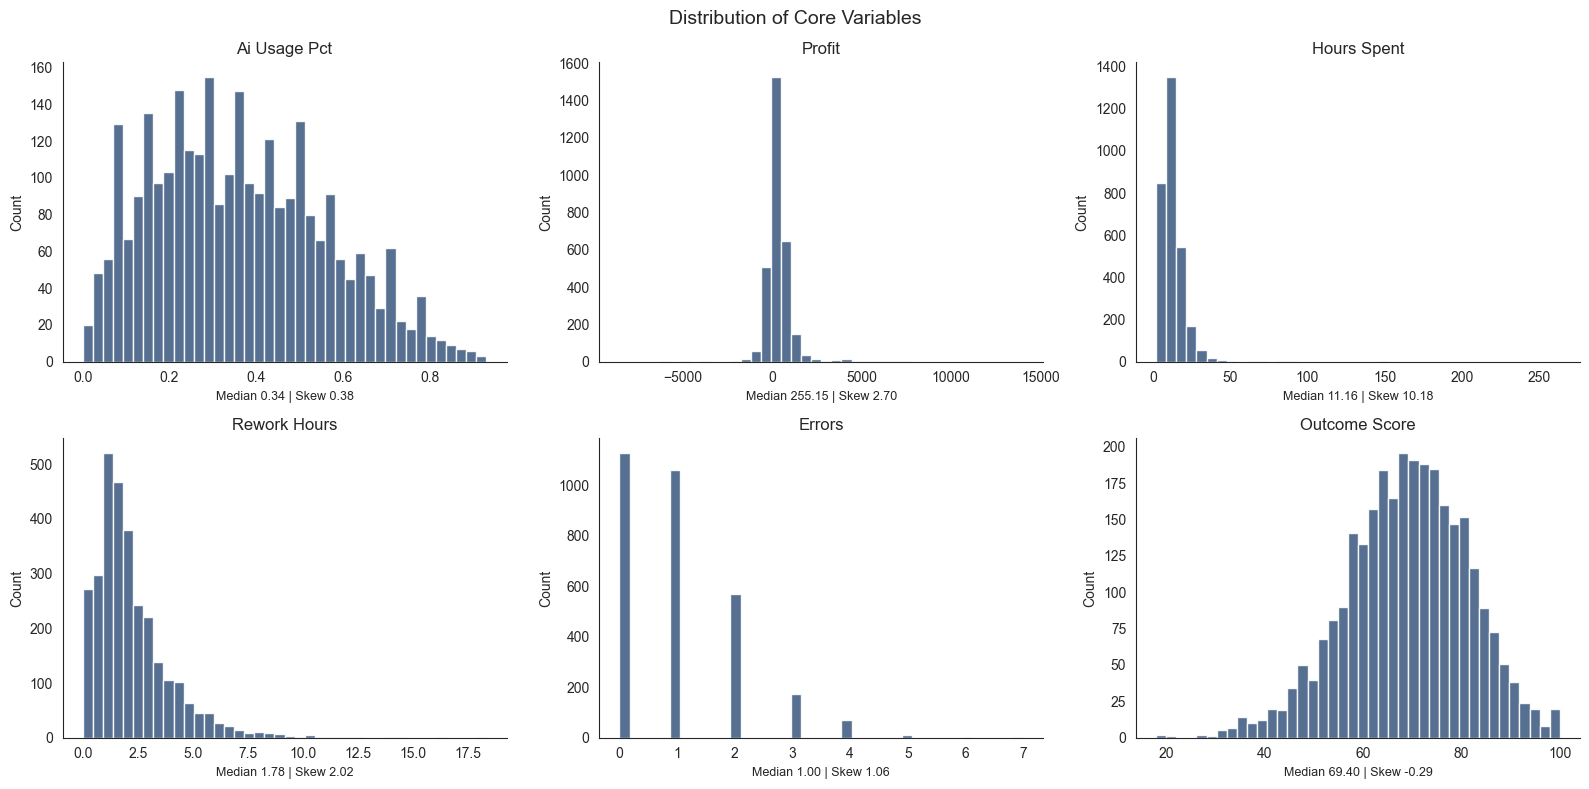

In [22]:
import os
os.makedirs('images', exist_ok=True)

core_vars = ['ai_usage_pct', 'profit', 'hours_spent', 'rework_hours', 'errors', 'outcome_score']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, var in zip(axes.flat, core_vars):
    data = df[var].dropna()
    ax.hist(data, bins=40, color=C1, edgecolor='white', alpha=0.9)
    ax.set_title(var.replace('_', ' ').title())
    ax.set_xlabel(f'Median {data.median():.2f} | Skew {data.skew():.2f}', fontsize=9)
    ax.set_ylabel('Count')
    finish_ax(ax)

plt.suptitle('Distribution of Core Variables', fontsize=14)
plt.tight_layout()
plt.savefig('images/01_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

- AI Usage Pct: The distribution is slightly right-skewed (Skew: 0.38) with a median of 0.34. Most tasks fall within the 0.2 to 0.5 range, indicating that while AI is integrated, it rarely handles the vast majority of a task's requirements.

- Hours Spent: This variable is highly positively skewed (Skew: 10.18). While the median is low at 11.16 hours, there are extreme outliers reaching up to 250 hours, suggesting a small number of tasks are significantly more complex than the norm.

- Rework Hours: Most tasks require minimal rework (Median: 1.78 hours). However, the distribution shows a "long tail," meaning some tasks suffer from disproportionately high revision needs.

- Profit: Profitability is heavily clustered around the median of 255.15, but the  skewness (2.70) indicates a "right tail." There are rare "home run" tasks that generate high profit (up to 15,000), while some tasks actually result in a loss (negative values).

- Errors: This is a discrete distribution where the majority of tasks result in 0 or 1 error. The count drops off sharply after 3 errors, showing a generally high standard of initial output, though the maximum reaches 7.

- Outcome Score: This is the most "normal" looking distribution, though it is slightly left-skewed (Skew: -0.29). With a high median of 69.40, it suggests that the processes in place are consistently producing quality results, with the bulk of scores falling between 60 and 85.

### AI Usage vs Outcomes: Decile Means ± 95% CI (Q1 & Q2)

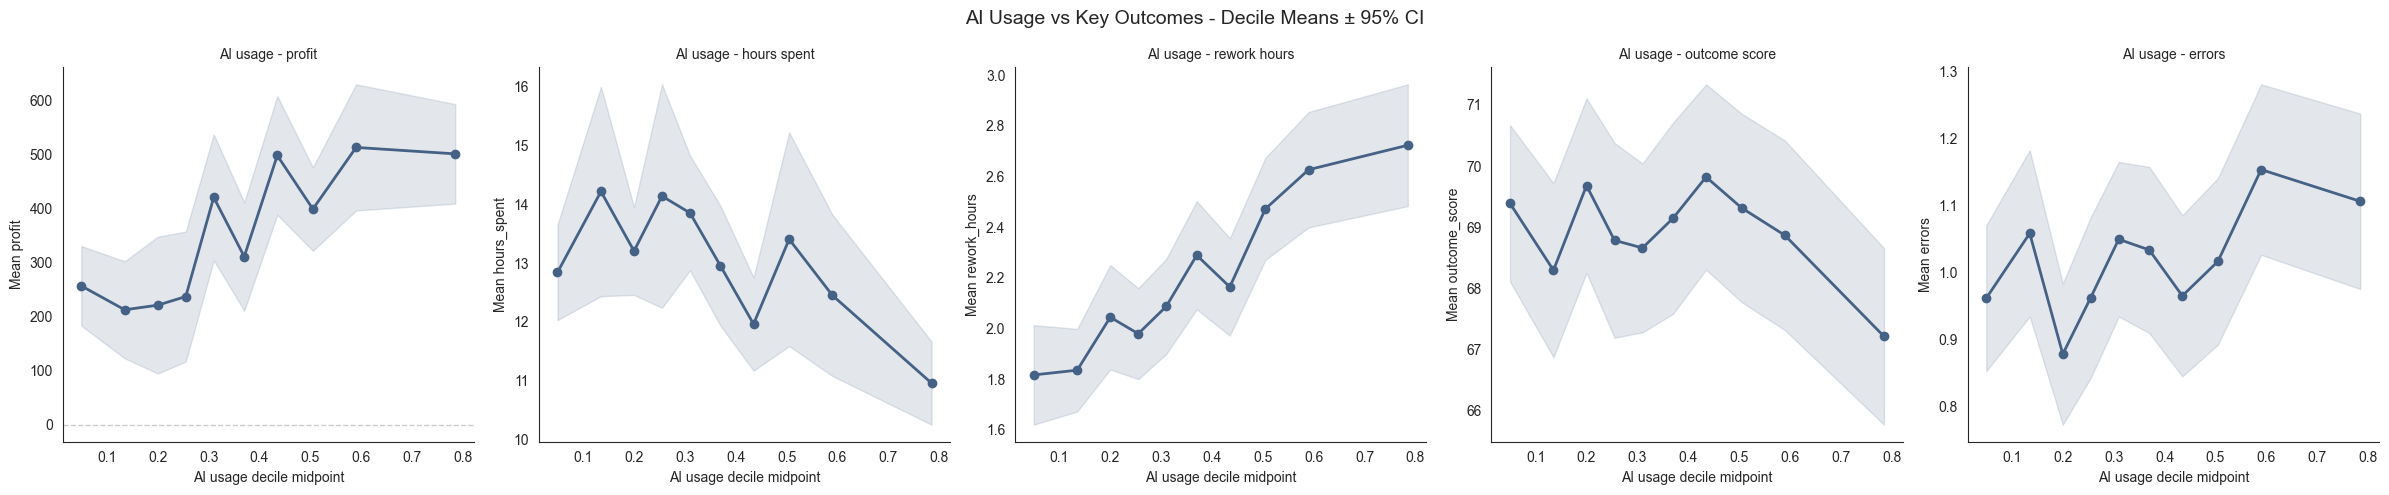

In [23]:
outcome_pairs = [
    ('profit',        'AI usage - profit'),
    ('hours_spent',   'AI usage - hours spent'),
    ('rework_hours',  'AI usage - rework hours'),
    ('outcome_score', 'AI usage - outcome score'),
    ('errors',        'AI usage - errors'),
]

fig, axes = plt.subplots(1, 5, figsize=(24, 5))

for ax, (var, title) in zip(axes, outcome_pairs):
    data = df.dropna(subset=['ai_usage_pct', var]).copy()
    data['ai_bin'] = pd.qcut(data['ai_usage_pct'], q=10, duplicates='drop')
    binned = data.groupby('ai_bin', observed=True)[var].agg(['mean', 'sem'])
    midpoints = [iv.mid for iv in binned.index]
    means = binned['mean']
    ci = 1.96 * binned['sem']

    ax.plot(midpoints, means, marker='o', linewidth=2, color=C1)
    ax.fill_between(midpoints, means - ci, means + ci, alpha=0.15, color=C1)
    if var == 'profit':
        ax.axhline(0, color=CGREY, linewidth=1, linestyle='--')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('AI usage decile midpoint')
    ax.set_ylabel(f'Mean {var}')
    finish_ax(ax)

plt.suptitle('AI Usage vs Key Outcomes - Decile Means ± 95% CI', fontsize=14)
plt.tight_layout()
plt.savefig('images/02_decile_means.png', bbox_inches='tight', dpi=150)
plt.show()

* **Profit growth is non-linear and accelerating:** Average profit rises monotonically from approximately **€225** in the lowest decile to **€514** in the highest. Notably, the most aggressive gains occur after AI usage crosses the **40% threshold**, suggesting a "sweet spot" for financial return.
* **Significant time savings:** There is a steady decline in **hours_spent** as AI usage increases, resulting in approximately **4 hours saved** per task when comparing the lowest usage groups to the highest.
* **Rising operational friction:** Conversely, **rework_hours** (and to a lesser extent, **errors**) trend upward in higher deciles. This suggests that the speed gains mentioned above are partially eroded by the need for more frequent corrections at high levels of AI integration.
* **Quality stability and late decline:** The **outcome_score** remains largely stable for most of the distribution, though it begins a visible decline after the **60–70% decile midpoints**. This indicates that while general quality holds firm, there may be a threshold where over-reliance begins to impact the final deliverable.
* **Increased variance at the extremes:** The **95% confidence intervals** widen significantly in the top deciles. This reflects both the smaller sample sizes of "power users" and a higher degree of outcome variance, signaling that extreme AI usage introduces more performance volatility.

### Outcome Distributions and Risk Rates by AI Band (Q3)

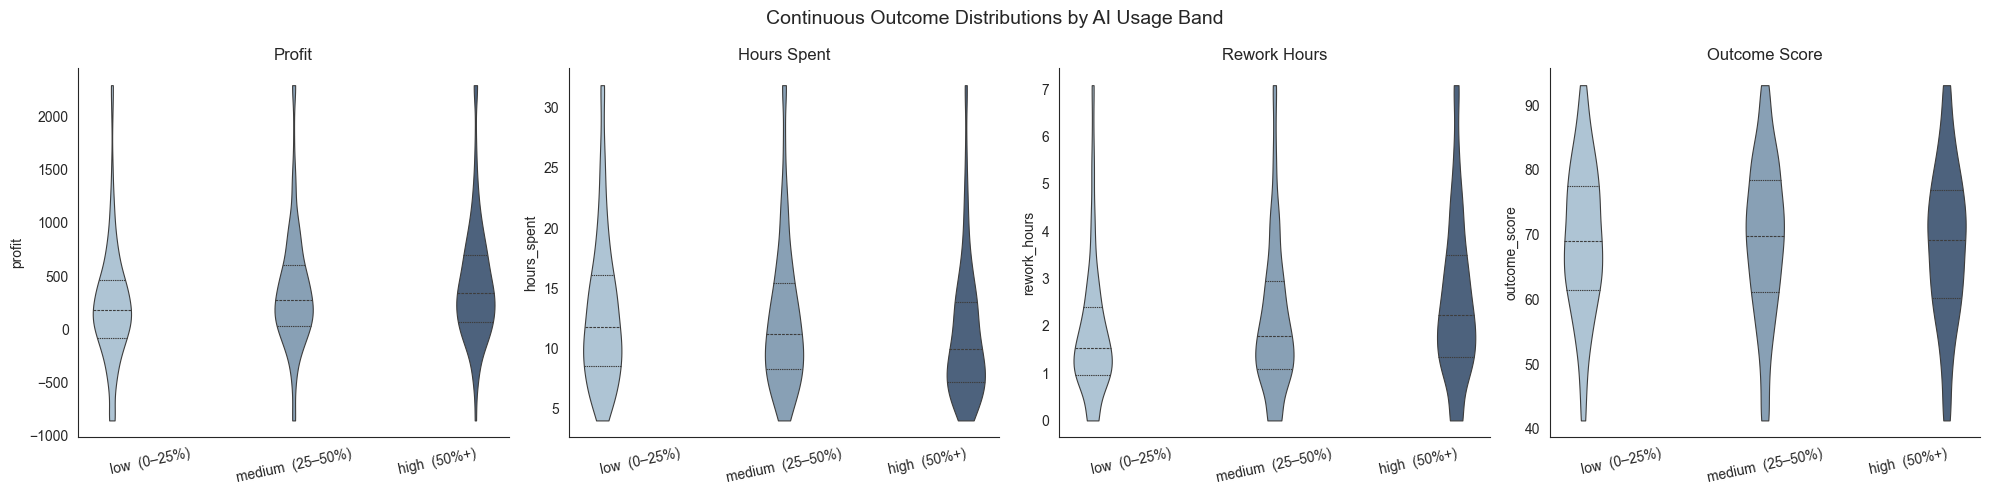

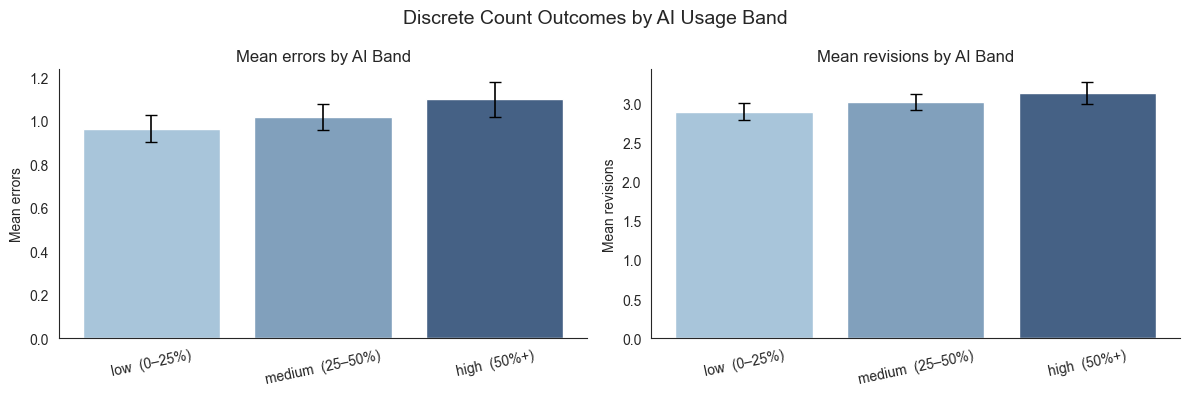

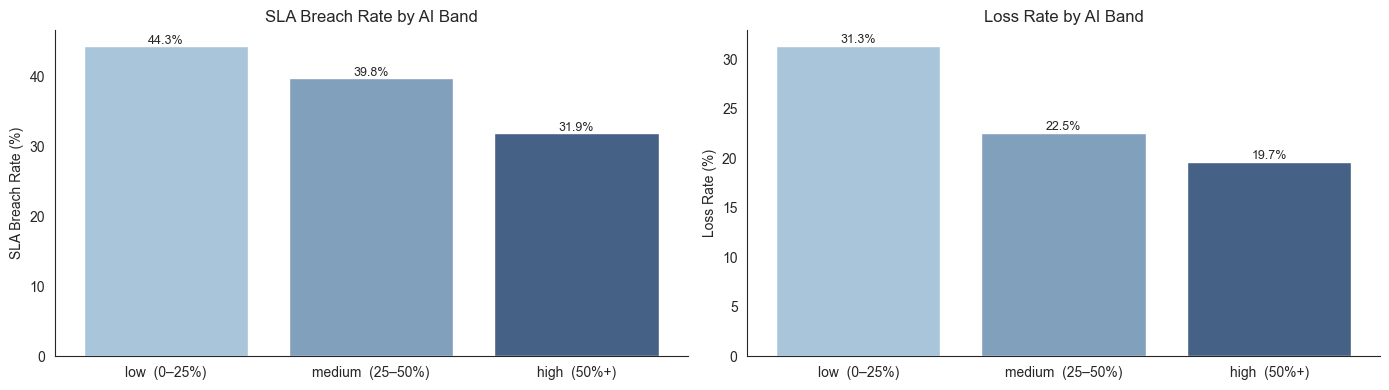

In [24]:
df_bands = df.dropna(subset=['ai_band'])

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, var in zip(axes, ['profit', 'hours_spent', 'rework_hours', 'outcome_score']):
    lo, hi = df[var].quantile(0.02), df[var].quantile(0.98)
    plot_data = df_bands.dropna(subset=[var]).copy()
    plot_data[var] = plot_data[var].clip(lo, hi)
    sns.violinplot(
        data=plot_data, x='ai_band', y=var, hue='ai_band', order=band_order, hue_order=band_order,
        palette=band_palette, ax=ax, inner='quartile', cut=0, linewidth=0.8, legend=False
    )
    ax.set_title(var.replace('_', ' ').title())
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelrotation=12)
    finish_ax(ax)

plt.suptitle('Continuous Outcome Distributions by AI Usage Band', fontsize=14)
plt.tight_layout()
plt.savefig('images/03_outcome_violins.png', bbox_inches='tight', dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, var in zip(axes, ['errors', 'revisions']):
    stats = df_bands.groupby('ai_band', observed=True)[var].agg(['mean', 'sem']).reindex(band_order)
    ax.bar(
        band_order, stats['mean'], yerr=1.96 * stats['sem'],
        color=band_colors, edgecolor='white', capsize=4, error_kw={'elinewidth': 1.2}
    )
    ax.set_title(f'Mean {var} by AI Band')
    ax.set_ylabel(f'Mean {var}')
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelrotation=12)
    finish_ax(ax)

plt.suptitle('Discrete Count Outcomes by AI Usage Band', fontsize=14)
plt.tight_layout()
plt.savefig('images/03_outcome_bars.png', bbox_inches='tight', dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (col, label) in zip(axes, [('sla_breach', 'SLA Breach Rate'), ('is_loss', 'Loss Rate')]):
    rate = df_bands.groupby('ai_band', observed=True)[col].mean().reindex(band_order).mul(100)
    bars = ax.bar(band_order, rate, color=band_colors, edgecolor='white')
    ax.set_ylabel(f'{label} (%)')
    ax.set_title(f'{label} by AI Band')
    for bar, val in zip(bars, rate):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.3, f'{val:.1f}%', ha='center', fontsize=9)
    finish_ax(ax)

plt.tight_layout()
plt.savefig('images/03_outcome_rates.png', bbox_inches='tight', dpi=150)
plt.show()

* Mean profit doubles from €232 (low AI) to €474 (high AI), a +€242 expected uplift per task
* SLA breach rate falls 12 percentage points (44% → 32%) across the three AI bands
* Loss rate falls 11 percentage points (31% → 19.7%) from the low to the high band
* Profit variance increases with AI usage, the high band generates more upside and more downside simultaneously
* The distribution shift is driven primarily by fewer extreme losses, not just higher averages

### Speed–Quality Trade-off by AI Band

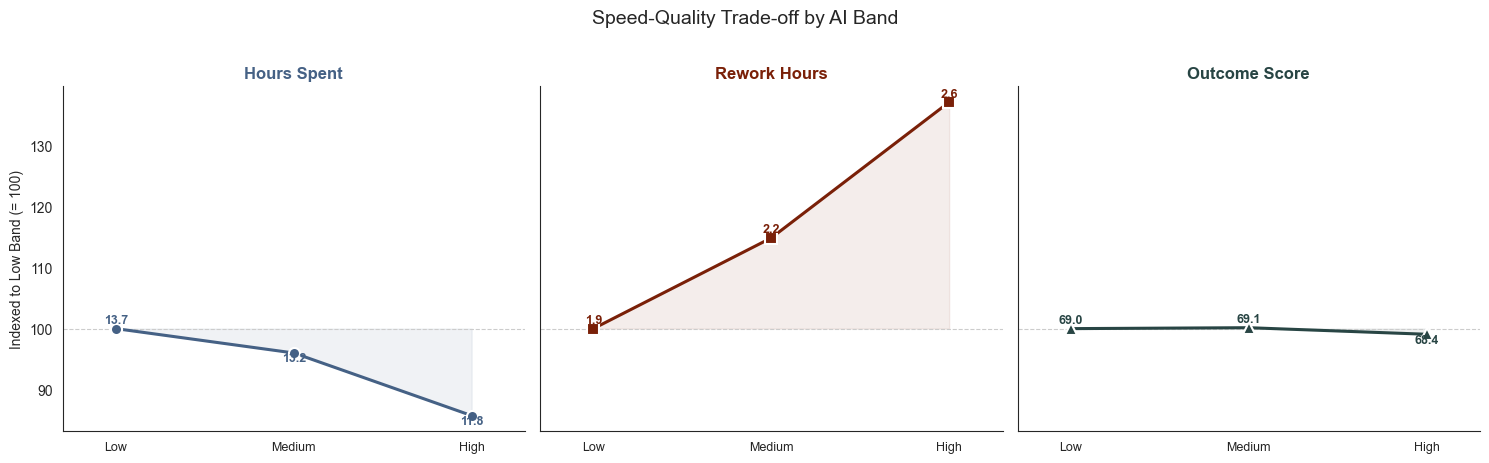

In [25]:
speed_quality = (
    df_bands.groupby('ai_band', observed=True)
    [['hours_spent', 'rework_hours', 'outcome_score']]
    .mean()
    .reindex(band_order)
)

indexed = speed_quality.div(speed_quality.iloc[0]).mul(100)

labels = ['Hours Spent', 'Rework Hours', 'Outcome Score']
colors = [C1, C6, C3]
icons  = ['o', 's', '^']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, col, label, color, icon in zip(axes, indexed.columns, labels, colors, icons):
    vals = indexed[col]
    raw  = speed_quality[col]

    ax.plot(range(3), vals, marker=icon, color=color, linewidth=2.2,
            markersize=8, markeredgecolor='white', markeredgewidth=1.5, zorder=3)
    ax.fill_between(range(3), 100, vals, alpha=0.08, color=color)
    ax.axhline(100, color=CGREY, linewidth=0.8, linestyle='--', zorder=1)

    for i, (v, r) in enumerate(zip(vals, raw)):
        offset = 4 if v >= 100 else -6
        ax.annotate(f'{r:.1f}', (i, v), textcoords='offset points',
                    xytext=(0, offset), ha='center', fontsize=9, color=color, fontweight='bold')

    ax.set_title(label, fontsize=12, color=color, fontweight='bold')
    ax.set_xticks(range(3))
    ax.set_xticklabels(['Low', 'Medium', 'High'], fontsize=9)
    ax.set_xlim(-0.3, 2.3)
    finish_ax(ax)

axes[0].set_ylabel('Indexed to Low Band (= 100)', fontsize=10)

plt.suptitle('Speed-Quality Trade-off by AI Band', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('images/04_speed_quality_tradeoff.png', bbox_inches='tight', dpi=150)
plt.show()

* `hours_spent` drops from 13.7 h (low AI) to 11.8 h (high AI), a ~2 h speed gain per task
* `rework_hours` rises from 1.9 h to 2.6 h, offsetting ~0.9 h of the time saved
* Net efficiency gain is approximately 1.1 h per task, not the headline 2 h figure
* `outcome_score` stays flat at ~69 across all bands, AI neither improves nor degrades perceived quality on average
* Quality risk is not visible in averages; it manifests in the tail 

### Segmentation by Task Context (Q4)

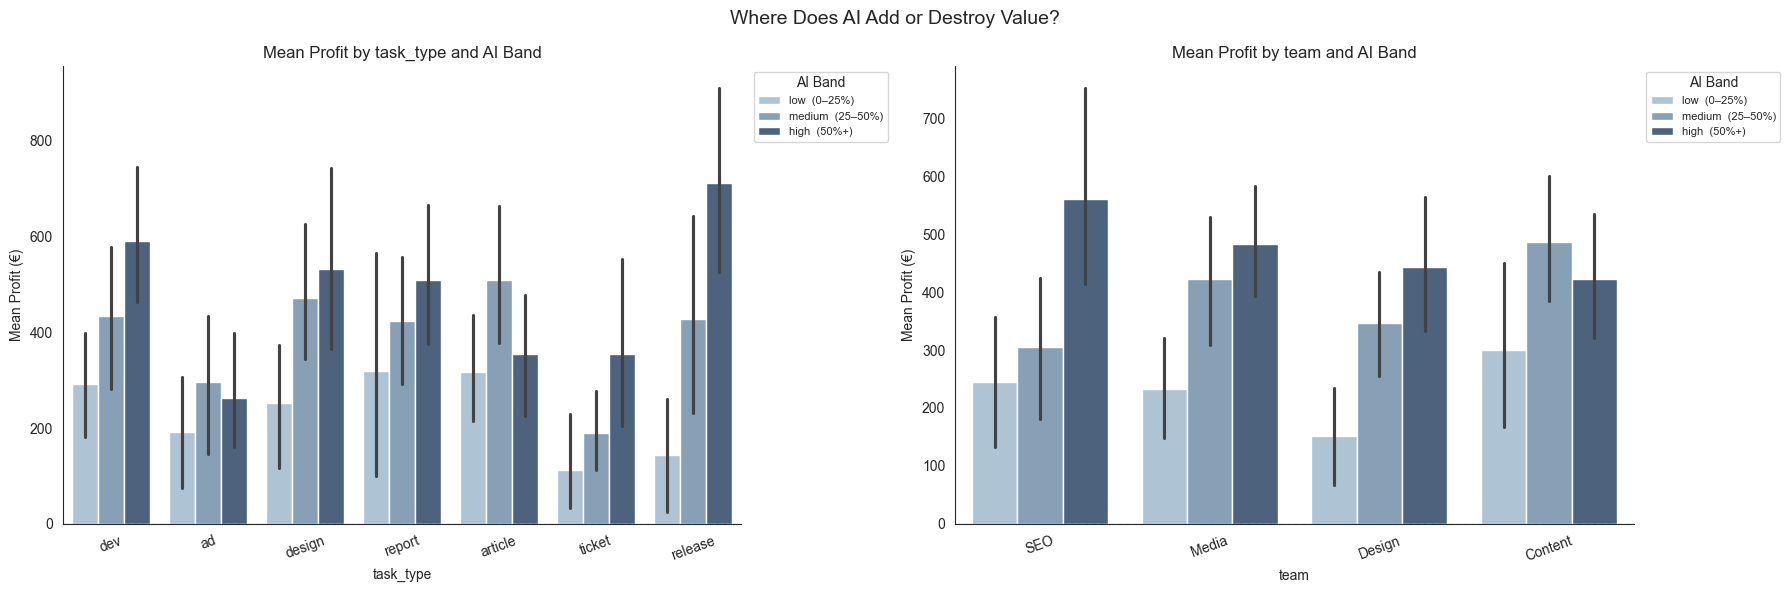

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, seg in zip(axes, ['task_type', 'team']):
    sns.barplot(
        data=df.dropna(subset=['ai_band']),
        x=seg, y='profit',
        hue='ai_band',
        hue_order=band_order,
        palette=band_palette,
        estimator='mean',
        errorbar=('ci', 95),
        ax=ax
    )
    ax.set_title(f'Mean Profit by {seg} and AI Band')
    ax.set_xlabel(seg)
    ax.set_ylabel('Mean Profit (€)')
    ax.tick_params(axis='x', labelrotation=20)
    ax.axhline(0, color=CGREY, linewidth=1, linestyle='--')
    ax.legend(title='AI Band', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
    finish_ax(ax)

plt.suptitle('Where Does AI Add or Destroy Value?', fontsize=14)
plt.tight_layout()
plt.savefig('images/05_segmentation_type_team.png', bbox_inches='tight', dpi=150)
plt.show()

* **Inverted-U Patterns:** Both **article** and **ad** tasks exhibit diminishing returns, where profit peaks in the medium band but falls at high AI usage, suggesting a threshold where over-automation begins to erode margins.
* **High-Growth Workflows (Tickets, Release, Dev, Design, Report):** These categories represent the strongest AI dividends, with profit reaching its maximum in the high (50%+) usage band. 
* **Tiered Team Impact**: The benefit of AI is distributed unevenly across departments; SEO captures the most significant and consistent profit gains at high usage, while Media and Design also show continued growth. Conversely, the Content team mirrors the article trend, experiencing a visible profit decline when moving from medium to high AI integration.
* **Workflow Sensitivity:** The data confirms that AI value is highly dependent on task type; it acts as a powerful multiplier for technical or structured tasks like releases and tickets but hits a clear performance ceiling in creative or content-heavy workflows.

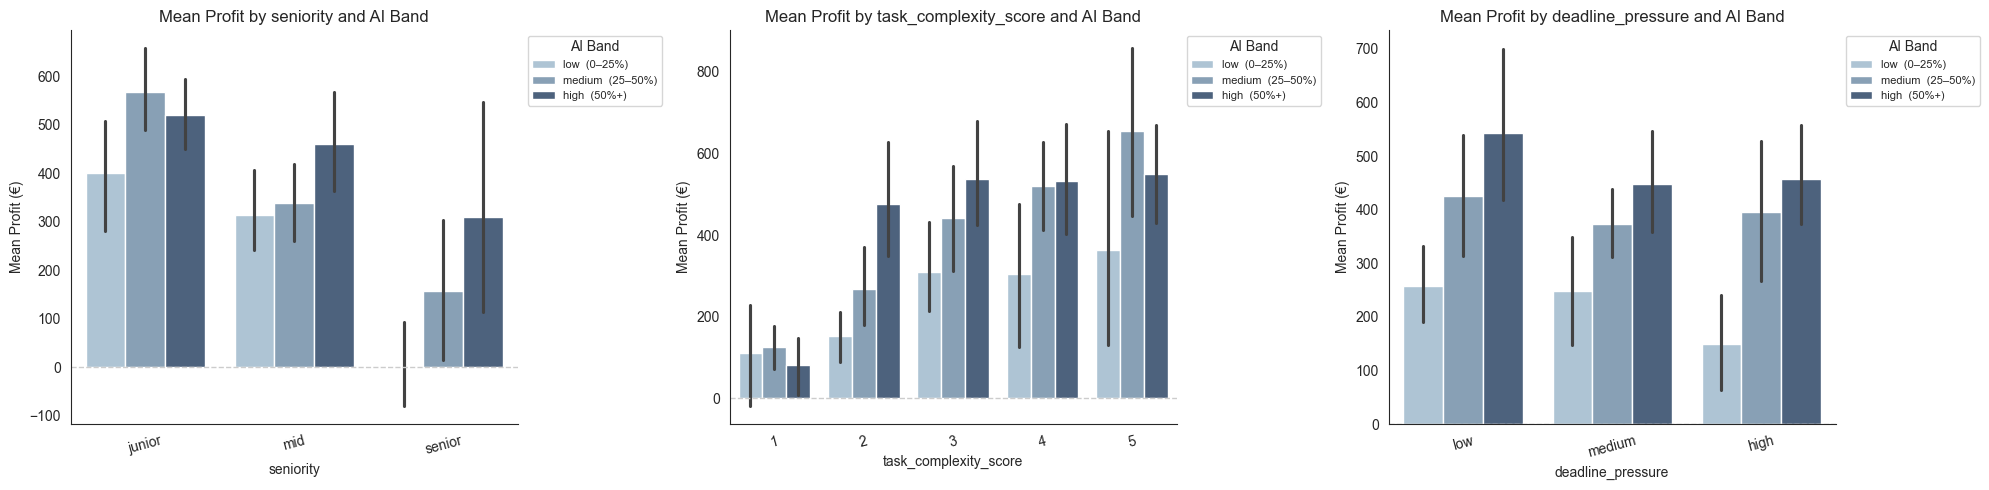

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

seniority_order = ['junior', 'mid', 'senior']

for ax, seg in zip(axes, ['seniority', 'task_complexity_score', 'deadline_pressure']):
    current_order = seniority_order if seg == 'seniority' else None
    sns.barplot(
        data=df.dropna(subset=['ai_band']),
        x=seg, y='profit',
        hue='ai_band',
        hue_order=band_order,
        order=current_order,
        palette=band_palette,
        estimator='mean',
        errorbar=('ci', 95),
        ax=ax
    )
    ax.set_title(f'Mean Profit by {seg} and AI Band')
    ax.set_xlabel(seg)
    ax.set_ylabel('Mean Profit (€)')
    ax.tick_params(axis='x', labelrotation=15)
    ax.axhline(0, color=CGREY, linewidth=1, linestyle='--')
    ax.legend(title='AI Band', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
    finish_ax(ax)

plt.tight_layout()
plt.savefig('images/06_segmentation_seniority.png', bbox_inches='tight', dpi=150)
plt.show()

* **Seniority and the AI Skill Gap:** Junior contributors exhibit an inverted-U pattern where profit peaks at medium AI usage and declines at high usage, whereas senior contributors see their profit nearly double as they move into the high AI band. This suggests that senior staff possess the expertise to leverage AI for complex gains, while juniors may struggle with quality control or diminishing returns at high automation levels.

* **The Complexity "Sweet Spot":** AI integration proves most beneficial for mid-level complexity, specifically scores 2 through 4, where profit scales significantly with higher usage. However, high AI usage is not beneficial at the extremes; for very simple tasks (score 1), the overhead of AI may outweigh the gains, and for the most difficult tasks (score 5), profit actually dips at high usage levels compared to the medium band, indicating that extreme complexity still requires a human-centric approach.

* **Deadlines as a Performance Lever:** Profit scales consistently with AI usage across all levels of deadline pressure, with the most pronounced gains occurring under high-pressure scenarios. This identifies AI as a critical tool for maintaining high margins during urgent delivery windows, effectively acting as an efficiency multiplier when timelines are compressed.

### Seniority × Pricing Model: Profit Heatmap



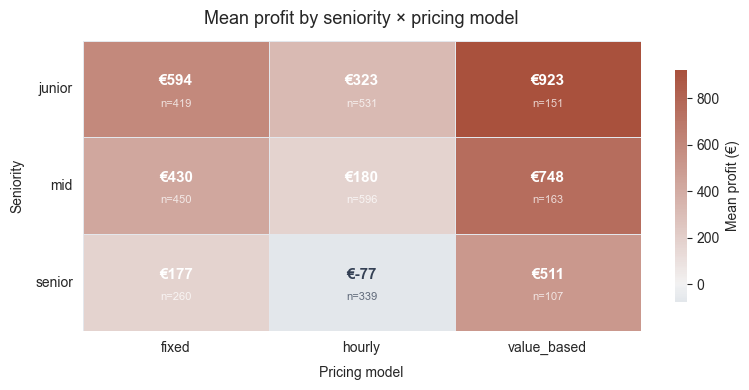

In [28]:
seniority_order  = ['junior', 'mid', 'senior']
pricing_order    = ['fixed', 'hourly', 'value_based']

pivot_mean  = (
    df.dropna(subset=['seniority', 'pricing_model', 'profit'])
    .groupby(['seniority', 'pricing_model'])['profit']
    .mean()
    .unstack('pricing_model')
    .reindex(index=seniority_order, columns=pricing_order)
)

pivot_count = (
    df.dropna(subset=['seniority', 'pricing_model', 'profit'])
    .groupby(['seniority', 'pricing_model'])['profit']
    .count()
    .unstack('pricing_model')
    .reindex(index=seniority_order, columns=pricing_order)
)

fig, ax = plt.subplots(figsize=(8, 4))

sns.heatmap(
    pivot_mean,
    ax=ax,
    cmap=heatmap_cmap,
    center=0,
    annot=False,
    linewidths=0.5,
    linecolor="#E4E7EC",
    cbar_kws={"label": "Mean profit (€)", "shrink": 0.8},
)

for row_i, sen in enumerate(seniority_order):
    for col_i, pm in enumerate(pricing_order):
        val = pivot_mean.loc[sen, pm]
        n   = pivot_count.loc[sen, pm]
        if pd.notna(val):
            txt_color = "white" if abs(val) > 150 else "#344054"
            ax.text(
                col_i + 0.5, row_i + 0.42,
                f"€{val:,.0f}",
                ha="center", va="center",
                fontsize=11, fontweight="bold", color=txt_color,
            )
            ax.text(
                col_i + 0.5, row_i + 0.65,
                f"n={n:,}",
                ha="center", va="center",
                fontsize=8, color=txt_color, alpha=0.75,
            )

ax.set_xlabel("Pricing model", labelpad=8)
ax.set_ylabel("Seniority", labelpad=8)
ax.set_title("Mean profit by seniority × pricing model", fontsize=13, pad=12)
ax.set_xticklabels(pricing_order, rotation=0)
ax.set_yticklabels(seniority_order, rotation=0)

plt.tight_layout()
plt.savefig('images/07_heatmap_seniority_pricing.png', bbox_inches='tight', dpi=150)
plt.show()

* **junior + value_based:** This is the most profitable combination in the entire dataset, yielding **€923** per task. 
* **junior + fixed:** Shows strong performance at **€594**, significantly outperforming more senior levels in the same category.
* **junior + hourly:** The least profitable junior model at **€323**, yet it remains positive and more efficient than senior hourly work.
* **mid + value_based:** Generates a solid **€748**, following the trend that value-based pricing yields higher margins for all levels.
* **mid + fixed:** Produces a moderate **€430** per task.
* **mid + hourly:** Results in the lowest positive margin for this group at **€180**.
* **senior + value_based:** The only senior category with a strong margin at **€511**, highlighting that seniors need output-based pricing to be profitable.
* **senior + fixed:** Shows a low return of **€177**, likely due to high senior costs eating into the fixed fee.
* **senior + hourly:** The only negative cell in the matrix at **-€77**, indicating that hourly billing for senior staff is currently a loss-making endeavor.

### Correlation Heatmap

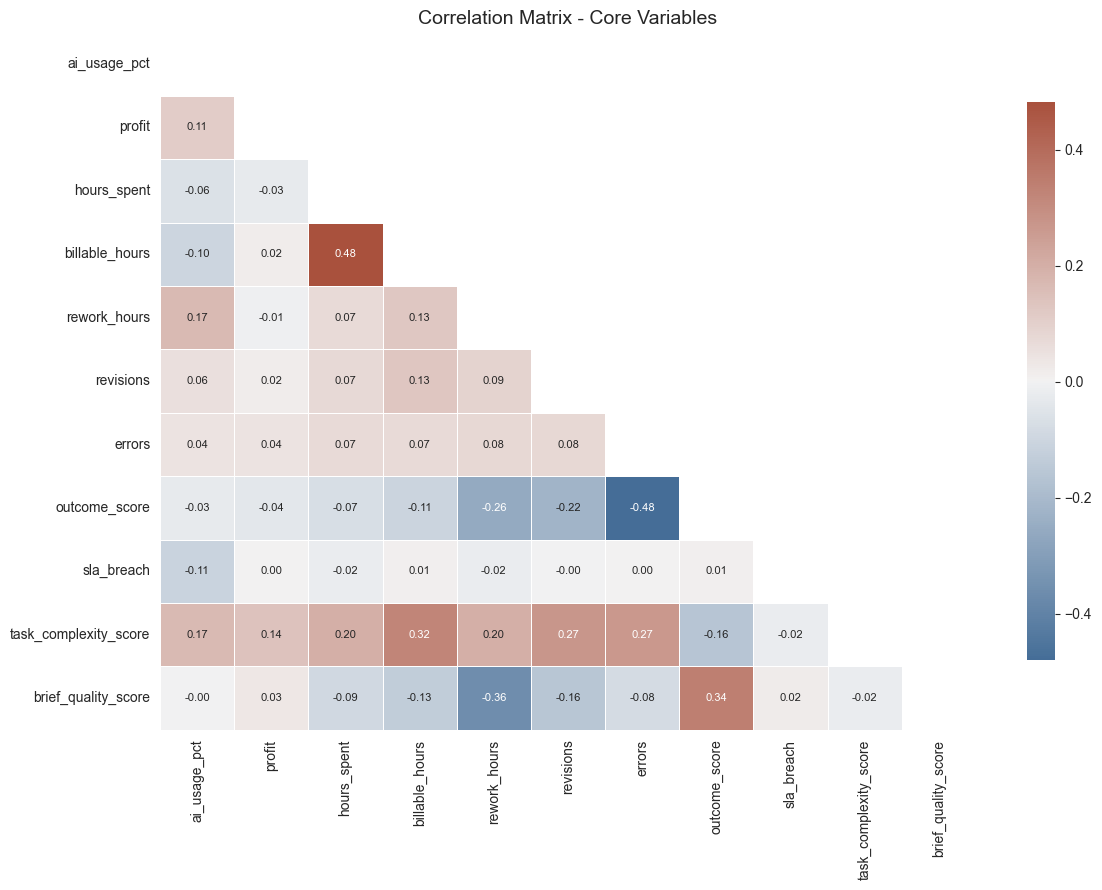

In [29]:
corr_vars = ['ai_usage_pct', 'profit', 'hours_spent', 'billable_hours',
             'rework_hours', 'revisions', 'errors', 'outcome_score',
             'sla_breach', 'task_complexity_score', 'brief_quality_score']

corr = df[corr_vars].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap=heatmap_cmap,
    center=0, linewidths=0.4, ax=ax, annot_kws={'size': 8},
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Matrix - Core Variables', fontsize=14)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.savefig('images/08_correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

The correlation matrix reveals the following primary relationships among core operational and performance variables:

* **AI Usage and Efficiency:** `ai_usage_pct` has a positive correlation with **profit (0.11)** and a negative correlation with **sla_breach (-0.11)**, suggesting that higher AI integration generally improves financial margins and helps meet deadlines.

* **The AI Quality Tax:** Increasing `ai_usage_pct` is positively correlated with **rework_hours (0.17)** and **task_complexity_score (0.17)**, indicating that AI is frequently deployed on harder tasks but results in a higher volume of necessary corrections.

* **Quality Drivers and Blockers:** `outcome_score` is most strongly undermined by **errors (-0.48)** and **rework_hours (-0.26)**; conversely, it is positively influenced by **brief_quality_score (0.34)**, highlighting that a good starting brief is a critical predictor of final quality.

* **Complexity and Friction:** `task_complexity_score` shows broad positive correlations with **billable_hours (0.32)**, **revisions (0.27)**, and **errors (0.27)**, confirming that more complex work naturally drives higher administrative and correction overhead.

* **Brief Quality Impact:** A low `brief_quality_score` is strongly associated with an increase in **rework_hours (-0.36)**, reinforcing the conclusion that poor instructions are a primary driver of wasted labor.

* **Labor Dynamics:** **hours_spent** and **billable_hours** share a moderate positive correlation **(0.48)**, which is expected, but the gap suggests that a significant portion of labor time is not always directly billed to the client.

### Scope Changes 

14% of tasks had scope changes during execution.

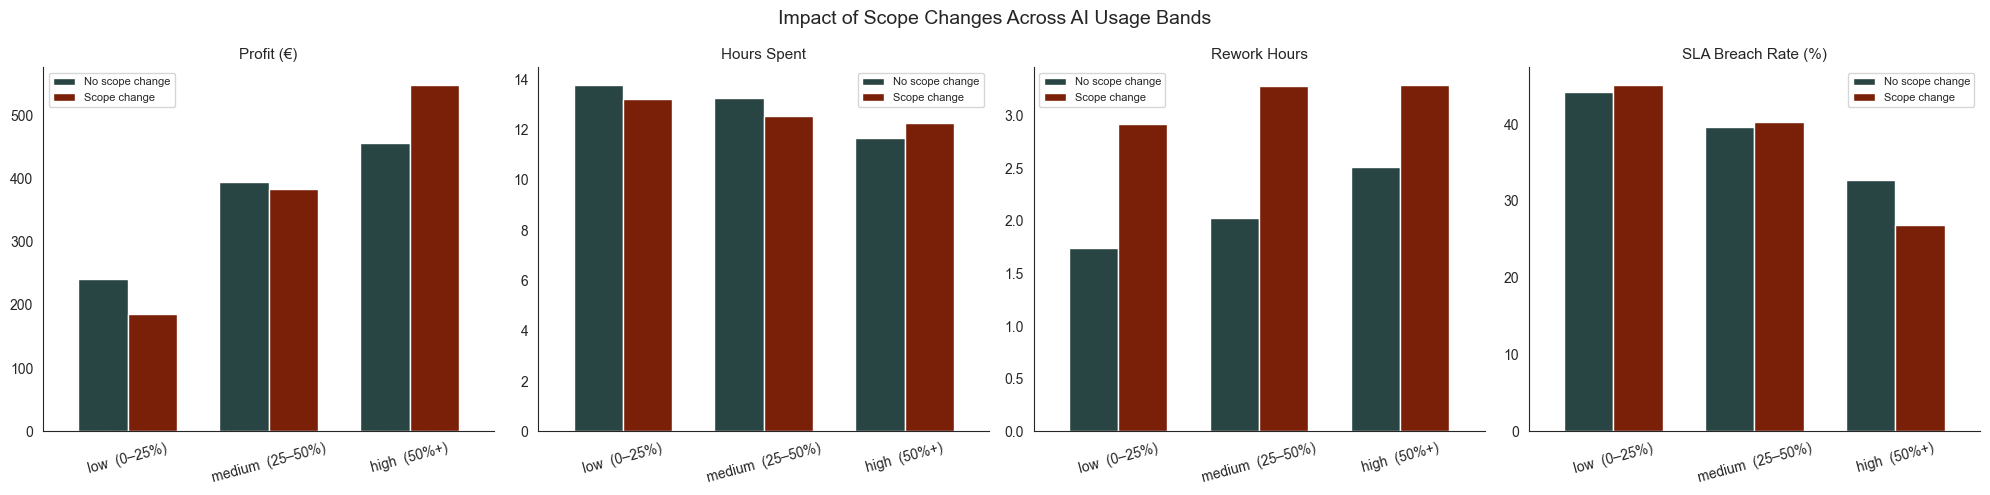

In [30]:
df_scope = df.dropna(subset=['ai_band']).copy()
df_scope['scope_label'] = df_scope['scope_change_flag'].map({0: 'No scope change', 1: 'Scope change'})

metrics = ['profit', 'hours_spent', 'rework_hours', 'sla_breach']
titles  = ['Profit (€)', 'Hours Spent', 'Rework Hours', 'SLA Breach Rate (%)']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, var, title in zip(axes, metrics, titles):
    pivot = (
        df_scope.groupby(['ai_band', 'scope_label'], observed=True)[var]
        .mean()
        .unstack('scope_label')
        .reindex(band_order)
    )
    if var == 'sla_breach':
        pivot = pivot * 100

    pivot.plot.bar(
        ax=ax, color=[C3, C6], edgecolor='white', width=0.7
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelrotation=15)
    ax.legend(fontsize=8, loc='best')
    if var == 'profit':
        ax.axhline(0, color=CGREY, linewidth=0.8, linestyle='--')
    finish_ax(ax)

plt.suptitle('Impact of Scope Changes Across AI Usage Bands', fontsize=14)
plt.tight_layout()
plt.savefig('images/09_scope_changes.png', bbox_inches='tight', dpi=150)
plt.show()

* **Profit Recovery:** In low and medium AI bands, scope changes act as a "profit killer," reducing margins compared to stable tasks. However, in the **high (50%+)** band, this trend reverses-tasks with scope changes actually achieve the highest mean profit in the dataset, suggesting AI allows teams to absorb additional work profitably.
* **Hours Spent Paradox:** For low and medium usage, scope changes surprisingly show lower total hours than stable tasks, possibly indicating early abandonment or rushed delivery. At high usage, scope changes drive **higher hours spent**, indicating that the team is successfully putting in the extra labor required to fulfill the new requirements.
* **Rework Escalation:** Scope changes consistently drive a significant spike in **rework_hours** across all bands. While AI helps manage the financial impact, it does not eliminate the friction; rework remains highest (over 3 hours) for tasks with scope changes regardless of AI intensity.
* **SLA Resilience:** The most striking impact is on the **SLA Breach Rate**. While scope changes usually increase the risk of missing deadlines in lower bands, they lead to a significant **decrease** in breaches within the high AI band. This suggests that high AI usage provides the necessary "burst capacity" to pivot and complete expanded scopes within the original timeframe.
* **Operational Conclusion:** High AI usage effectively transforms "scope creep" from a risk into an opportunity, allowing the agency to maintain high profit and improved deadline compliance even when task requirements shift mid-stream.

### Missing Data Pattern: `ai_usage_pct`

`ai_usage_pct` is the central variable in the entire analysis, yet 144 values (4.4%) are missing. Before trusting any AI-band finding we need to verify the missingness is not concentrated in a specific team, task type, or seniority level,which would introduce systematic bias.

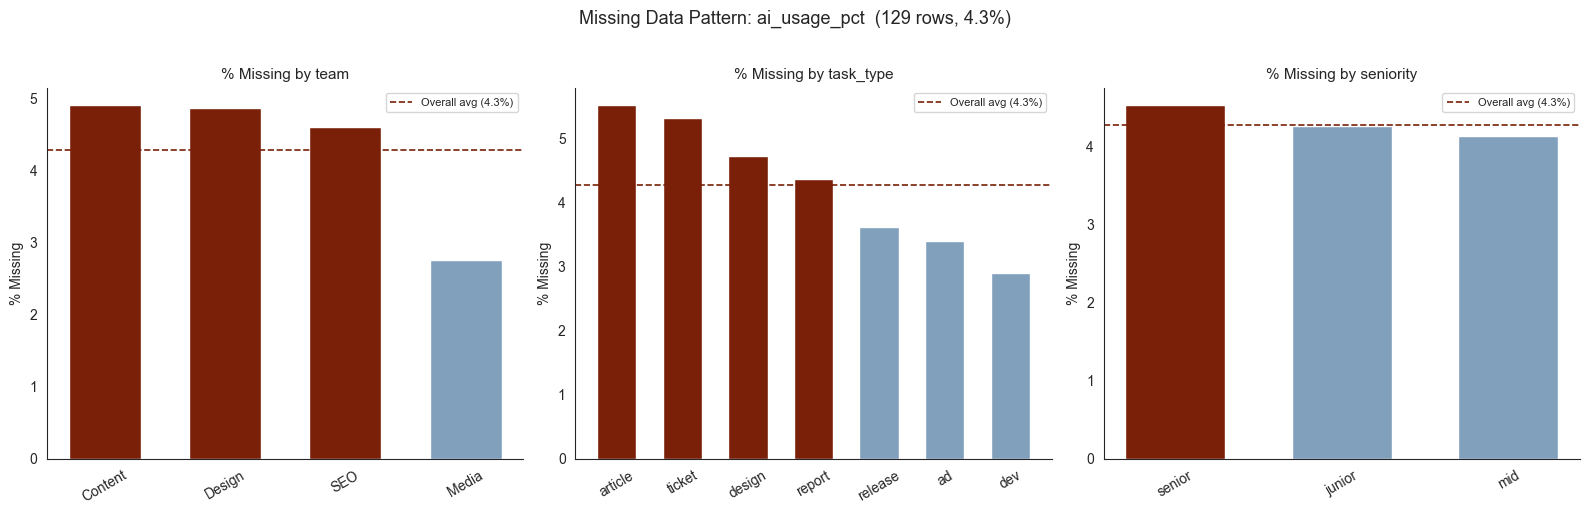

In [31]:
missing_mask  = df['ai_usage_pct'].isna()
total_missing = missing_mask.sum()
overall_pct   = total_missing / len(df) * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['team', 'task_type', 'seniority']):
    miss_rate = (
        df.groupby(col)['ai_usage_pct']
          .apply(lambda x: x.isna().mean() * 100)
          .sort_values(ascending=False)
    )
    bar_colors = [C6 if v > overall_pct else C2 for v in miss_rate]
    ax.bar(miss_rate.index, miss_rate.values, color=bar_colors, edgecolor='white', width=0.6)
    ax.axhline(overall_pct, color=C6, linestyle='--', linewidth=1.2,
               label='Overall avg ({:.1f}%)'.format(overall_pct))
    ax.set_title('% Missing by {}'.format(col), fontsize=11)
    ax.set_ylabel('% Missing')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)
    finish_ax(ax)

plt.suptitle(
    'Missing Data Pattern: ai_usage_pct  ({} rows, {:.1f}%)'.format(total_missing, overall_pct),
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig('images/22_missing_ai_usage.png', dpi=150, bbox_inches='tight')
plt.show()

### Rework Threshold: Where Does Rework Cancel the Speed Gain?

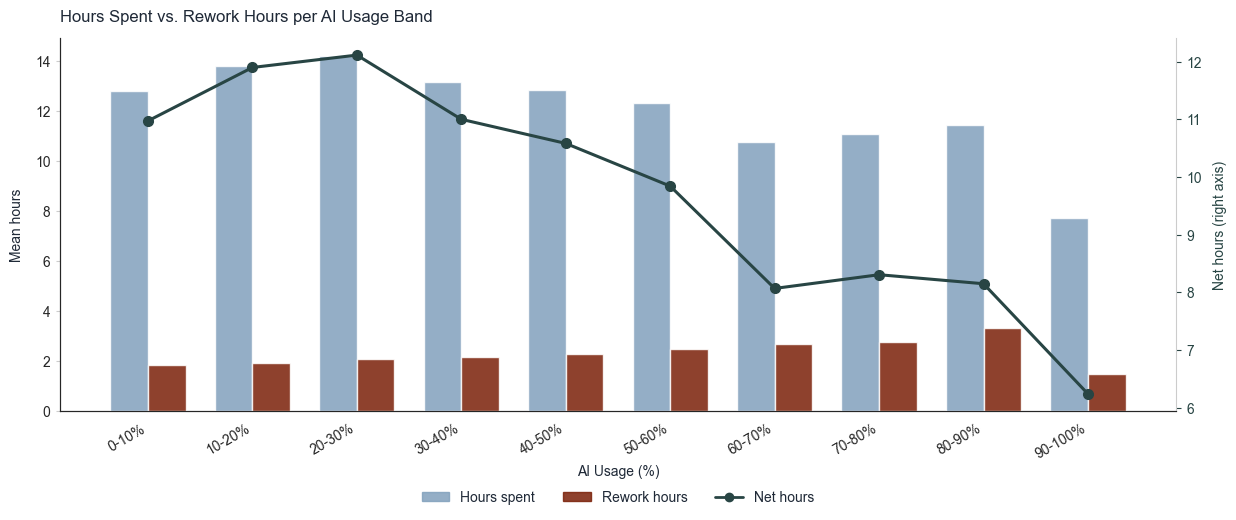

In [32]:
bins10 = np.linspace(0, 1, 11)
labs10 = [f'{int(i*100)}-{int((i+0.1)*100)}%' for i in np.linspace(0, 0.9, 10)]

df_m = df.dropna(subset=['ai_usage_pct','hours_spent','rework_hours',
                          'profit','outcome_score','pricing_model']).copy()
df_m['ai_bin']       = pd.cut(df_m['ai_usage_pct'], bins=bins10,
                               labels=labs10, include_lowest=True)
df_m['net_hours']    = df_m['hours_spent'] - df_m['rework_hours']
df_m['rework_ratio'] = df_m['rework_hours'] / df_m['hours_spent']
df_m['is_loss']      = (df_m['profit'] < 0).astype(int)

grp = (df_m.groupby('ai_bin', observed=True)
       .agg(hours_mean   =('hours_spent',  'mean'),
            rework_mean  =('rework_hours', 'mean'),
            net_hours    =('net_hours',    'mean'),
            rework_ratio =('rework_ratio', 'mean'),
            n            =('profit',       'count'))
       .reset_index())

baseline_hours  = grp['hours_mean'].iloc[0]
baseline_rework = grp['rework_mean'].iloc[0]
grp['speed_gain']   = baseline_hours  - grp['hours_mean']
grp['rework_added'] = grp['rework_mean'] - baseline_rework
grp['net_gain']     = grp['speed_gain'] - grp['rework_added']

x      = np.arange(len(grp))
w      = 0.36
labels = grp['ai_bin'].tolist()

fig, ax1 = plt.subplots(figsize=(13, 6), facecolor='white')

ax1.bar(x - w/2, grp['hours_mean'],  w, color=C2, alpha=0.85, zorder=3)
ax1.bar(x + w/2, grp['rework_mean'], w, color=C6, alpha=0.85, zorder=3)

ax1b = ax1.twinx()
ax1b.plot(x, grp['net_hours'], color=C3, marker='o', linewidth=2.2,
          markersize=7, zorder=4)
ax1b.spines['right'].set_visible(True)
ax1b.spines['right'].set_color(CGREY)
ax1b.spines['top'].set_visible(False)
ax1b.tick_params(axis='y', colors=C3, labelsize=10)
ax1.set_xlabel('AI Usage (%)', color=CDARK, labelpad=2)

ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=30, ha='right')
ax1.set_ylabel('Mean hours', color=CDARK, labelpad=8)
ax1b.set_ylabel('Net hours (right axis)', color=C3, labelpad=8)
ax1.set_title('Hours Spent vs. Rework Hours per AI Usage Band',
              fontsize=12, color=CDARK, pad=12, loc='left')
ax1.set_ylim(bottom=0)
ax1.tick_params(axis='x', length=4, color=CGREY)
ax1.tick_params(axis='y', length=3, color=CGREY)

patch_hours  = mpatches.Patch(color=C2,  alpha=0.85, label='Hours spent')
patch_rework = mpatches.Patch(color=C6,  alpha=0.85, label='Rework hours')
line_net     = plt.Line2D([0],[0], color=C3, marker='o', linewidth=2,
                          markersize=6, label='Net hours')
ax1.legend(handles=[patch_hours, patch_rework, line_net],
           loc='upper center', bbox_to_anchor=(0.5, -0.18),
           ncol=3, frameon=False, fontsize=10, labelcolor=CDARK)

plt.tight_layout(pad=3.0)
plt.savefig('images/10_rework_threshold.png', bbox_inches='tight', dpi=150)
plt.show()

In [33]:
df_m['ai_bin'].value_counts().sort_index()

ai_bin
0-10%      280
10-20%     434
20-30%     509
30-40%     463
40-50%     415
50-60%     318
60-70%     200
70-80%     108
80-90%      40
90-100%      3
Name: count, dtype: int64

* **The Efficiency Pivot:** A definitive productivity threshold occurs once AI usage crosses the **50–60%** mark. Beyond this point, **hours spent** (blue bars) begin a consistent decline, indicating that high-intensity AI integration is necessary to significantly compress the total time required for task delivery.

* **The Rising Rework Tax:** There is a steady upward trend in **rework hours** (red bars) as AI usage increases, peaking in the **80–90%** band. This confirms that while AI accelerates the initial output, it introduces a "quality tax" necessitating more iterative corrections as the human-in-the-loop oversight decreases.

* **Net Gain Dominance:** Despite the increase in rework, the **net hours** (dark line) trend sharply downward after the **20–30%** usage peak. This proves that the speed gains provided by AI are substantial enough to far outweigh the additional time spent on corrections, leading to a significantly lower total labor requirement at higher usage levels.

* **Extreme Usage Paradox and Sample Scarcity:** In the final **90–100%** band, both hours spent and rework hours drop significantly. However, this must be viewed with caution as the sample size drops to only **3 tasks**, compared to **509** in the **20–30%** band. This suggests that while total automation appears "cleaner," it currently represents a tiny fraction of highly specialized or perfectly optimized workflows.

* **Strategic Compression:** The data demonstrates that moving from minimal AI usage to the high-performance **60–70%** band reduces net hours from roughly **11** to **8**, representing a significant efficiency gain even before reaching the volatile, low-volume extremes.

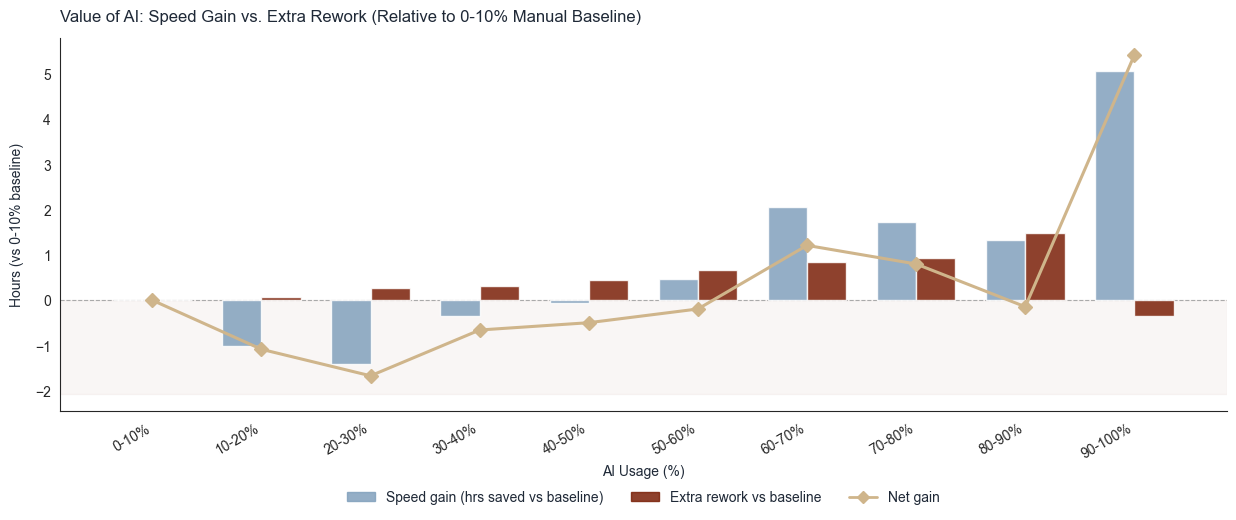

In [34]:
x      = np.arange(len(grp))
w      = 0.36
labels = grp['ai_bin'].tolist()

fig, ax2 = plt.subplots(figsize=(13, 6), facecolor='white')

ax2.bar(x - w/2, grp['speed_gain'],   w, color=C2, alpha=0.85, zorder=3)
ax2.bar(x + w/2, grp['rework_added'], w, color=C6, alpha=0.85, zorder=3)
ax2.plot(x, grp['net_gain'], color=C7, marker='D', linewidth=2.2,
         markersize=7, zorder=5)
ax2.axhline(0, color='#aaaaaa', linewidth=0.8, linestyle='--')
ax2.axhspan(grp['net_gain'].min() - 0.4, 0, alpha=0.04, color=C6, zorder=0)
ax2.set_xlabel('AI Usage (%)', color=CDARK, labelpad=2)

ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=30, ha='right')
ax2.set_ylabel('Hours (vs 0-10% baseline)', color=CDARK, labelpad=8)
ax2.set_title('Value of AI: Speed Gain vs. Extra Rework (Relative to 0-10% Manual Baseline)',
              fontsize=12, color=CDARK, pad=12, loc='left')
ax2.tick_params(axis='x', length=4, color=CGREY)
ax2.tick_params(axis='y', length=3, color=CGREY)

patch_speed   = mpatches.Patch(color=C2, alpha=0.85, label='Speed gain (hrs saved vs baseline)')
patch_rework2 = mpatches.Patch(color=C6, alpha=0.85, label='Extra rework vs baseline')
line_net2     = plt.Line2D([0],[0], color=C7, marker='D', linewidth=2,
                           markersize=6, label='Net gain')
ax2.legend(handles=[patch_speed, patch_rework2, line_net2],
           loc='upper center', bbox_to_anchor=(0.5, -0.18),
           ncol=3, frameon=False, fontsize=10, labelcolor=CDARK)

plt.tight_layout(pad=3.0)
plt.savefig('images/11_rework_value_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

The chart illustrates the "Value of AI" by measuring speed gains against extra rework relative to the manual baseline, identifying the specific threshold where AI becomes a net asset:

* **The "Incompetence Zone":** In the **10% to 50%** AI usage range, integration is consistently counterproductive. The negative speed gains and rising rework costs result in a net loss of time, suggesting that low-to-moderate AI usage adds process friction without providing enough acceleration to compensate.
* **The Break-Even Point:** A critical pivot occurs at the **60–70%** mark, where the speed gains finally begin to neutralize the "rework tax." This represents the threshold where the tool moves from being a liability to a neutral or slightly positive contributor.
* **High-Intensity Value:** Real operational dividends appear in the **60% to 100%** bands. In these high-usage segments, the speed gains (hours saved) substantially outpace the extra rework required, leading to the first significant positive net gains in the dataset.
* **Extreme Usage Volatility:** While the **90–100%** band shows a massive net gain of over 5 hours, it also shows a reduction in rework. As noted in previous views, this extreme performance is likely restricted to a very small number of highly specialized or perfectly optimized tasks.

### Hourly Model Sustainability: When Does Profit Break Under Hourly Pricing?

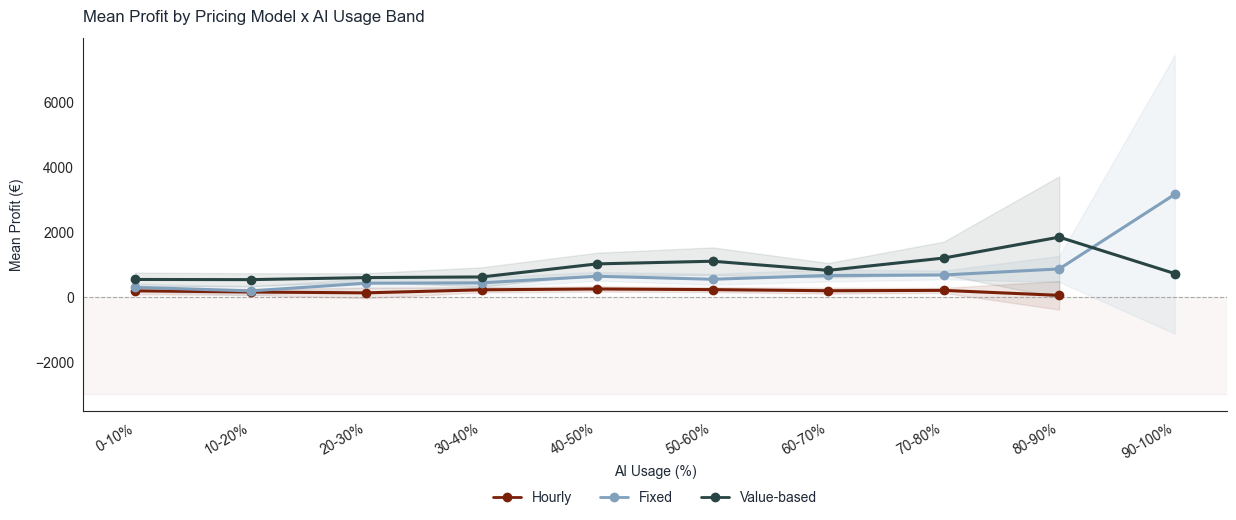

In [35]:
grp_price = (df_m.groupby(['pricing_model', 'ai_bin'], observed=True)
             .agg(profit_mean=('profit',  'mean'),
                  profit_std =('profit',  'std'),
                  loss_rate  =('is_loss', 'mean'),
                  n          =('profit',  'count'))
             .reset_index())

models = ['hourly', 'fixed', 'value_based']
colors = {'hourly': C6, 'fixed': C2, 'value_based': C3}
labels = {'hourly': 'Hourly', 'fixed': 'Fixed', 'value_based': 'Value-based'}

x = np.arange(len(labs10))

fig, ax1 = plt.subplots(figsize=(13, 6), facecolor='white')

ax1.axhline(0, color='#aaaaaa', linewidth=0.8, linestyle='--', zorder=2)
ax1.axhspan(ax1.get_ylim()[0] if ax1.get_ylim()[0] < 0 else -3000, 0,
            alpha=0.04, color=C6, zorder=1)

for m in models:
    sub = grp_price[grp_price['pricing_model'] == m].set_index('ai_bin').reindex(labs10)
    ci  = 1.96 * sub['profit_std'] / np.sqrt(sub['n'].clip(lower=1))
    ax1.plot(x, sub['profit_mean'], marker='o', markersize=6,
             color=colors[m], linewidth=2.2, label=labels[m], zorder=3)
    ax1.fill_between(x, sub['profit_mean'] - ci, sub['profit_mean'] + ci,
                     alpha=0.10, color=colors[m])

ax1.set_xticks(x)
ax1.set_xticklabels(labs10, rotation=30, ha='right')
ax1.set_ylabel('Mean Profit (€)', color=CDARK, labelpad=8)
ax1.set_title('Mean Profit by Pricing Model x AI Usage Band',
              fontsize=12, color=CDARK, pad=12, loc='left')
ax1.tick_params(axis='x', length=4, color=CGREY)
ax1.tick_params(axis='y', length=3, color=CGREY)
ax1.set_xlabel('AI Usage (%)', color=CDARK, labelpad=2)

handles = [mlines.Line2D([0],[0], color=colors[m], marker='o',
           linewidth=2, markersize=6, label=labels[m]) for m in models]
ax1.legend(handles=handles,
           loc='upper center', bbox_to_anchor=(0.5, -0.18),
           ncol=3, frameon=False, fontsize=10, labelcolor=CDARK)

plt.tight_layout(pad=3.0)
plt.savefig('images/12_pricing_model_profit.png', bbox_inches='tight', dpi=150)
plt.show()

The chart illustrates the critical relationship between pricing models and AI usage, highlighting how the agency captures or loses the value of automation:

* **Hourly Pricing Stagnation:** The **Hourly** model remains nearly flat and significantly lower than other models regardless of AI intensity. Because revenue is tied to time spent, every efficiency gain from AI simply reduces the billable amount, preventing the agency from converting productivity into profit.

* **Value-Based Dominance:** **Value-based** pricing consistently delivers the highest mean profit across almost all AI usage bands. This model allows the agency to decouple profit from labor hours, capturing the full "AI dividend" as margins increase alongside automation.

* **High-Band Value Shift:** At the extreme **90–100%** usage level, the **Value-based** mean profit shows a visible decrease. However, this dip is not considered statistically significant due to the very small number of observations in this band, as indicated by the wide confidence intervals.

* **The Fixed-Fee Breakout:** While **Fixed** pricing performs moderately for most of the curve, it shows a massive profit spike in the **90–100%** band. This suggests that when a task is fully automated under a set fee, the near-zero labor cost transforms the entire contract value into pure profit.

* **Extreme Usage Volatility:** At the end of the spectrum, both Fixed and Value-based models show very wide shaded regions. This indicates high outcome volatility; while the profit potential is enormous, the risk of significant loss also increases, likely due to the "rework tax" or potential quality failures at extreme automation levels.

* **Convergence at Low Usage:** Below **30%** AI usage, the choice of pricing model has a much smaller impact on the bottom line. The strategic advantage of switching to Fixed or Value-based models only becomes undeniable as the agency pushes into high-intensity AI integration.

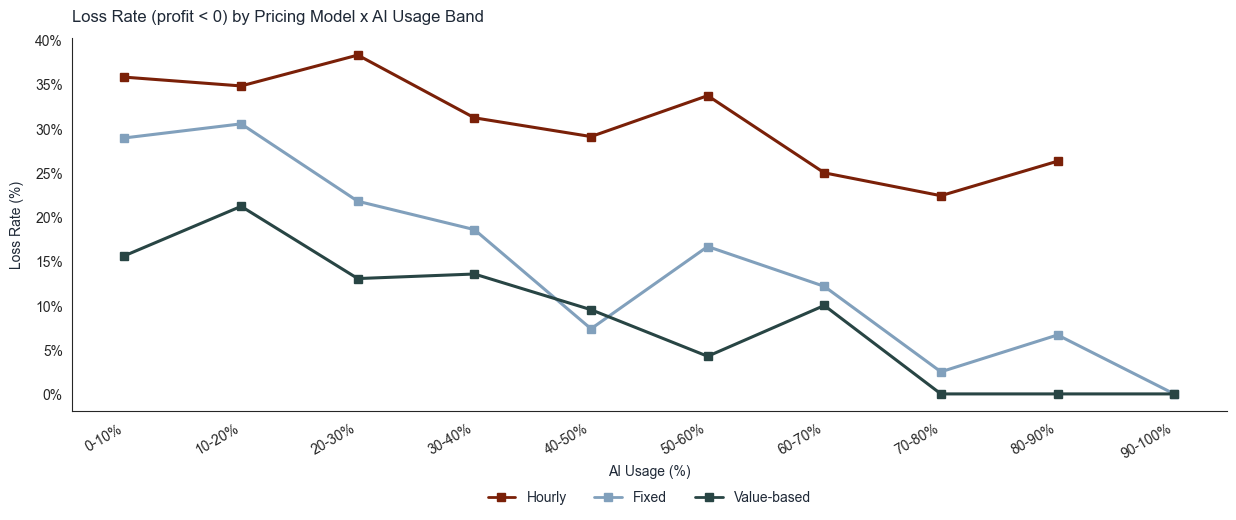

In [36]:
models = ['hourly', 'fixed', 'value_based']
colors = {'hourly': C6, 'fixed': C2, 'value_based': C3}
labels = {'hourly': 'Hourly', 'fixed': 'Fixed', 'value_based': 'Value-based'}

x = np.arange(len(labs10))

fig, ax2 = plt.subplots(figsize=(13, 6), facecolor='white')

for m in models:
    sub = grp_price[grp_price['pricing_model'] == m].set_index('ai_bin').reindex(labs10)
    ax2.plot(x, sub['loss_rate'] * 100, marker='s', markersize=6,
             color=colors[m], linewidth=2.2, label=labels[m], zorder=3)


ax2.set_xticks(x)
ax2.set_xticklabels(labs10, rotation=30, ha='right')
ax2.set_xlabel('AI Usage (%)', color=CDARK, labelpad=2)
ax2.set_ylabel('Loss Rate (%)', color=CDARK, labelpad=8)
ax2.set_title('Loss Rate (profit < 0) by Pricing Model x AI Usage Band',
              fontsize=12, color=CDARK, pad=12, loc='left')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax2.tick_params(axis='x', length=4, color=CGREY)
ax2.tick_params(axis='y', length=3, color=CGREY)

handles = [mlines.Line2D([0],[0], color=colors[m], marker='s',
           linewidth=2, markersize=6, label=labels[m]) for m in models]
ax2.legend(handles=handles,
           loc='upper center', bbox_to_anchor=(0.5, -0.18),
           ncol=3, frameon=False, fontsize=10, labelcolor=CDARK)

plt.tight_layout(pad=3.0)
plt.savefig('images/13_pricing_model_loss_rate.png', bbox_inches='tight', dpi=150)
plt.show()

The chart illustrates the loss rate - the percentage of tasks where profit is less than zero - across different pricing models and AI usage levels, showing that high-intensity automation is a powerful defense against financial loss:

* **Hourly Vulnerability:** The **Hourly** model consistently carries the highest risk of loss across almost all AI usage bands, peaking at nearly **38%** in the 20-30% range. This highlights that selling time is a high-risk strategy, as any inefficiency or rework quickly eats through the thin margins associated with hourly rates.

* **De-risking through Automation:** There is a clear downward trend in loss rates for all models as AI usage increases. By the time usage reaches the **70-80%** band, the loss rate for both **Value-based** and **Fixed** pricing drops to near zero, suggesting that AI provides the necessary efficiency cushion to ensure tasks remain profitable.

* **Value-Based Stability:** **Value-based** pricing is the most resilient model at lower levels of AI usage, maintaining a significantly lower loss rate than Fixed or Hourly. This indicates that pricing based on output rather than input provides a safer margin of error when automation is still being integrated.

* **The Fixed-Price Pivot:** The **Fixed** model shows high volatility in the mid-range (30-60%) but eventually converges with Value-based pricing at the highest automation levels. This reinforces the idea that when AI does the "heavy lifting," a set fee becomes a highly reliable way to guarantee profit.

###  Speed vs. Quality Trade-off: Where Does Quality Start to Break Down?

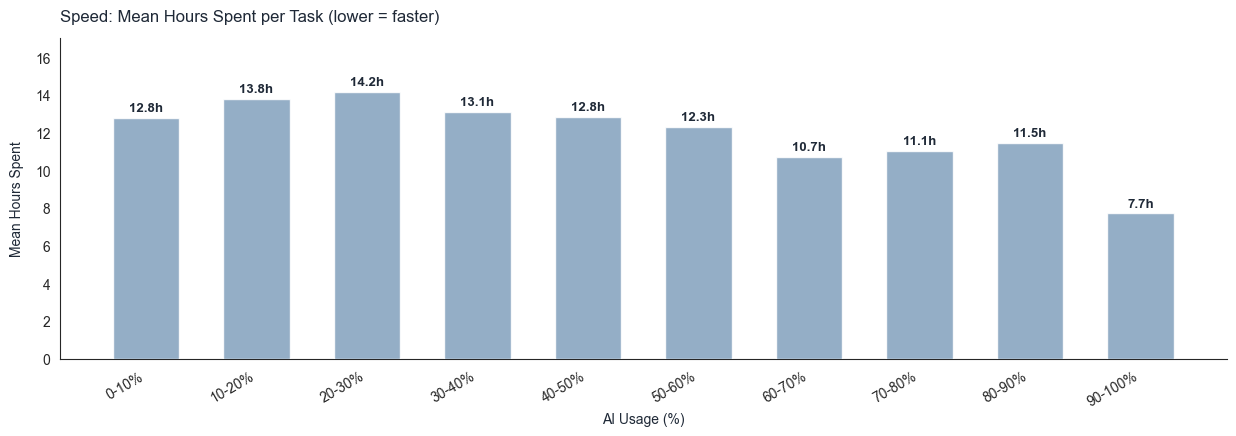

In [37]:
grp_q = (df_m.groupby('ai_bin', observed=True)
         .agg(hours_mean   =('hours_spent',   'mean'),
              score_mean   =('outcome_score', 'mean'),
              score_std    =('outcome_score', 'std'),
              score_p10    =('outcome_score', lambda x: np.percentile(x, 10)),
              loss_rate    =('is_loss',        'mean'),
              rework_ratio =('rework_ratio',   'mean'),
              n            =('profit',         'count'))
         .reset_index())

x = np.arange(len(grp_q))

fig, ax1 = plt.subplots(figsize=(13, 5), facecolor='white')

ax1.bar(x, grp_q['hours_mean'], color=C2, alpha=0.85, zorder=3, width=0.6)

for i, v in enumerate(grp_q['hours_mean']):
    ax1.text(i, v + 0.18, f'{v:.1f}h', ha='center', va='bottom',
             fontsize=9.5, color=CDARK, fontweight='bold')

ax1.set_xlabel('AI Usage (%)', color=CDARK, labelpad=2)
ax1.set_xticks(x)
ax1.set_xticklabels(grp_q['ai_bin'], rotation=30, ha='right')
ax1.set_ylabel('Mean Hours Spent', color=CDARK, labelpad=8)
ax1.set_title('Speed: Mean Hours Spent per Task (lower = faster)',
              fontsize=12, color=CDARK, pad=12, loc='left')
ax1.set_ylim(0, grp_q['hours_mean'].max() * 1.20)
ax1.tick_params(axis='x', length=4, color=CGREY)
ax1.tick_params(axis='y', length=3, color=CGREY)

plt.tight_layout(pad=3.0)
plt.savefig('images/14_speed_hours.png', bbox_inches='tight', dpi=150)
plt.show()

The chart tracks delivery speed by measuring the mean hours spent per task across increasing AI usage bands, revealing a non-linear relationship between automation and time savings:

* **Initial Friction (10–30%):** Low-to-moderate AI usage actually increases the time required to complete a task, peaking at **14.2 hours** in the 20–30% band compared to the 12.8-hour baseline. This indicates an "integration hump" where learning curves or tool experimentation add more time than they save.
* **The Efficiency Pivot (50%+):** Mean hours begin a consistent downward trend once AI usage crosses the **50% threshold**. This marks the point where the speed of AI generation finally overcomes the overhead of prompting and oversight.
* **Optimal Performance Zone (60–80%):** A significant efficiency gain is realized in the 60–70% band (**10.7h**), suggesting this is a highly effective "sweet spot" for human-AI collaboration before hitting more complex edge cases.
* **High-End Volatility (80–90%):** There is a slight uptick in time spent at **11.5 hours** in the 80–90% band. This likely reflects the "rework tax" seen in other data, where heavy AI usage on difficult tasks requires substantial manual correction time.
* **Extreme Automation Breakout:** The **90–100%** band shows the fastest delivery at **7.7 hours**, nearly a 40% reduction from the baseline. While highly efficient, this represents a small, specialized subset of the workflow that can be almost entirely automated.
* **Overall Impact:** The data proves that while "dabbling" in AI (under 30%) makes the agency slower, committed high-intensity usage (above 60%) provides a definitive and substantial speed advantage.

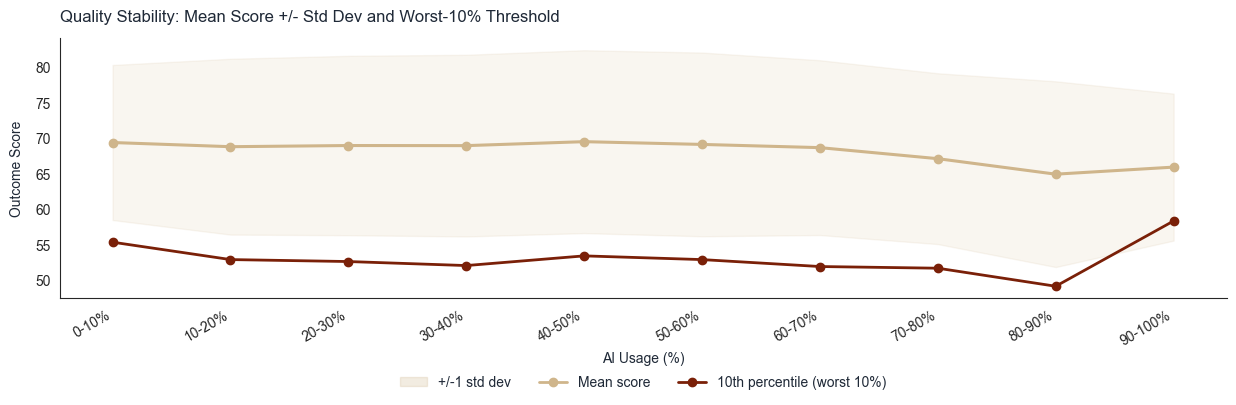

In [38]:
x = np.arange(len(grp_q))
fig, ax2 = plt.subplots(figsize=(13, 5), facecolor='white')

ax2.fill_between(x,
                 grp_q['score_mean'] - grp_q['score_std'],
                 grp_q['score_mean'] + grp_q['score_std'],
                 alpha=0.12, color=C7)
ax2.plot(x, grp_q['score_mean'], color=C7, marker='o', markersize=6,
         linewidth=2.2, zorder=4)
ax2.plot(x, grp_q['score_p10'], color=C6, marker='o', markersize=6,
         linewidth=2.0, zorder=4)

ax2.set_xlabel('AI Usage (%)', color=CDARK, labelpad=2)
ax2.set_xticks(x)
ax2.set_xticklabels(grp_q['ai_bin'], rotation=30, ha='right')
ax2.set_ylabel('Outcome Score', color=CDARK, labelpad=8)
ax2.set_title('Quality Stability: Mean Score +/- Std Dev and Worst-10% Threshold',
              fontsize=12, color=CDARK, pad=12, loc='left')
ax2.tick_params(axis='x', length=4, color=CGREY)
ax2.tick_params(axis='y', length=3, color=CGREY)

patch_std = mpatches.Patch(color=C7, alpha=0.25, label='+/-1 std dev')
line_mean = mlines.Line2D([0],[0], color=C7, marker='o', linewidth=2,
                           markersize=6, label='Mean score')
line_p10  = mlines.Line2D([0],[0], color=C6, marker='o', linewidth=2,
                           markersize=6, label='10th percentile (worst 10%)')
ax2.legend(handles=[patch_std, line_mean, line_p10],
           loc='upper center', bbox_to_anchor=(0.5, -0.25),
           ncol=3, frameon=False, fontsize=10, labelcolor=CDARK)
plt.tight_layout(pad=3.0)
plt.savefig('images/15_quality_stability.png', bbox_inches='tight', dpi=150)
plt.show()

The quality stability analysis reveals that the average outcome score remains remarkably resilient at approximately **70%**, proving that increasing AI integration does not inherently degrade the standard of work. While a slight quality dip and increased volatility occur in the **70–90%** "stress zone" - where the **10th percentile** hits its lowest point - the apparent recovery in the final **90–100%** band should be viewed with caution. As with previous metrics, this extreme band contains only a few observations, making the perceived quality stabilization in near-total automation statistically inconclusive compared to the high-volume mid-range bands. Consequently, the data suggests that while the average stays stable, human oversight remains most critical as usage approaches the 90% threshold to prevent inconsistent results.

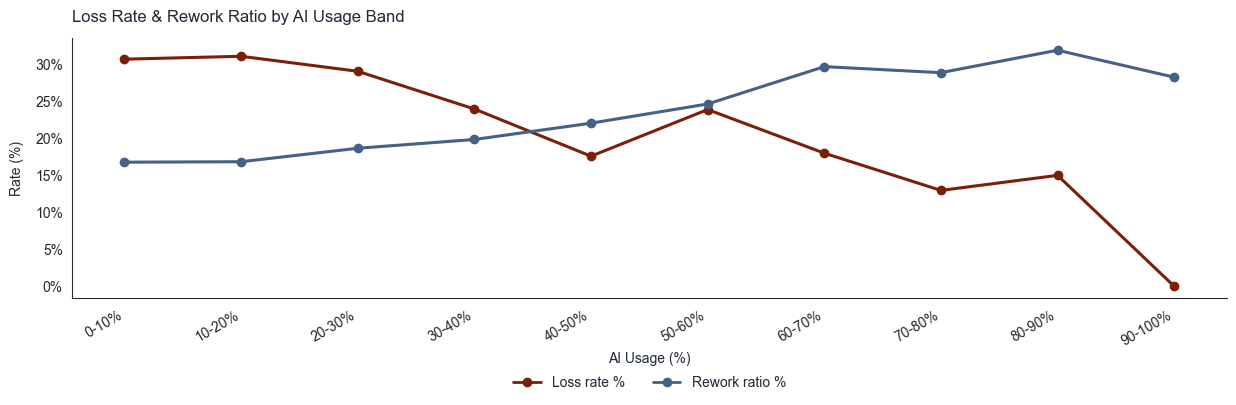

In [39]:
x = np.arange(len(grp_q))
fig, ax3 = plt.subplots(figsize=(13, 5), facecolor='white')

ax3.plot(x, grp_q['loss_rate'] * 100, color=C6, marker='o', markersize=6,
         linewidth=2.2, zorder=4)
ax3.plot(x, grp_q['rework_ratio'] * 100, color=C1, marker='o', markersize=6,
         linewidth=2.2, zorder=4)

ax3.set_xlabel('AI Usage (%)', color=CDARK, labelpad=2)
ax3.set_xticks(x)
ax3.set_xticklabels(grp_q['ai_bin'], rotation=30, ha='right')
ax3.set_ylabel('Rate (%)', color=CDARK, labelpad=8)
ax3.set_title('Loss Rate & Rework Ratio by AI Usage Band',
              fontsize=12, color=CDARK, pad=12, loc='left')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax3.tick_params(axis='x', length=4, color=CGREY)
ax3.tick_params(axis='y', length=3, color=CGREY)

line_loss   = mlines.Line2D([0],[0], color=C6, marker='o', linewidth=2,
                             markersize=6, label='Loss rate %')
line_rework = mlines.Line2D([0],[0], color=C1, marker='o', linewidth=2,
                             markersize=6, label='Rework ratio %')
ax3.legend(handles=[line_loss, line_rework],
           loc='upper center', bbox_to_anchor=(0.5, -0.25),
           ncol=2, frameon=False, fontsize=10, labelcolor=CDARK)
plt.tight_layout(pad=3.0)
plt.savefig('images/16_loss_rework_ratio.png', bbox_inches='tight', dpi=150)
plt.show()

* **Inverse Correlation:** There is a clear "X-shaped" trend where the **Loss rate %** (red line) decreases as the **Rework ratio %** (blue line) increases. This suggests that while AI introduces more iterative work, that same process is what ultimately prevents projects from becoming unprofitable.

* **Risk Mitigation through Iteration:** The **Loss rate** begins a sharp descent after the 20% mark, falling from over **30%** down to **15%** in the 80–90% band. This confirms that even as rework peaks at roughly **32%**, the efficiency gains of AI provide enough margin to absorb the extra correction time while still ensuring profitability.

* **The Break-Even Cross:** A significant intersection occurs between **50% and 60%** usage, where the rework ratio officially overtakes the loss rate. This represents a strategic pivot point for the business: moving from a "high risk of loss" environment to a "high rework but low risk" environment.

* **Operational Trade-off:** The data demonstrates that business health is not dependent on "getting it right the first time" with AI; rather, success is achieved by leveraging AI's speed to allow for multiple iterations (rework) without compromising the bottom line.

---
## Where Exactly Does AI Help and Where Does It Hurt?




### The AI Tipping Point Dashboard
*All key metrics normalized to baseline (0–10% AI = 0%) so divergence points become immediately visible.*


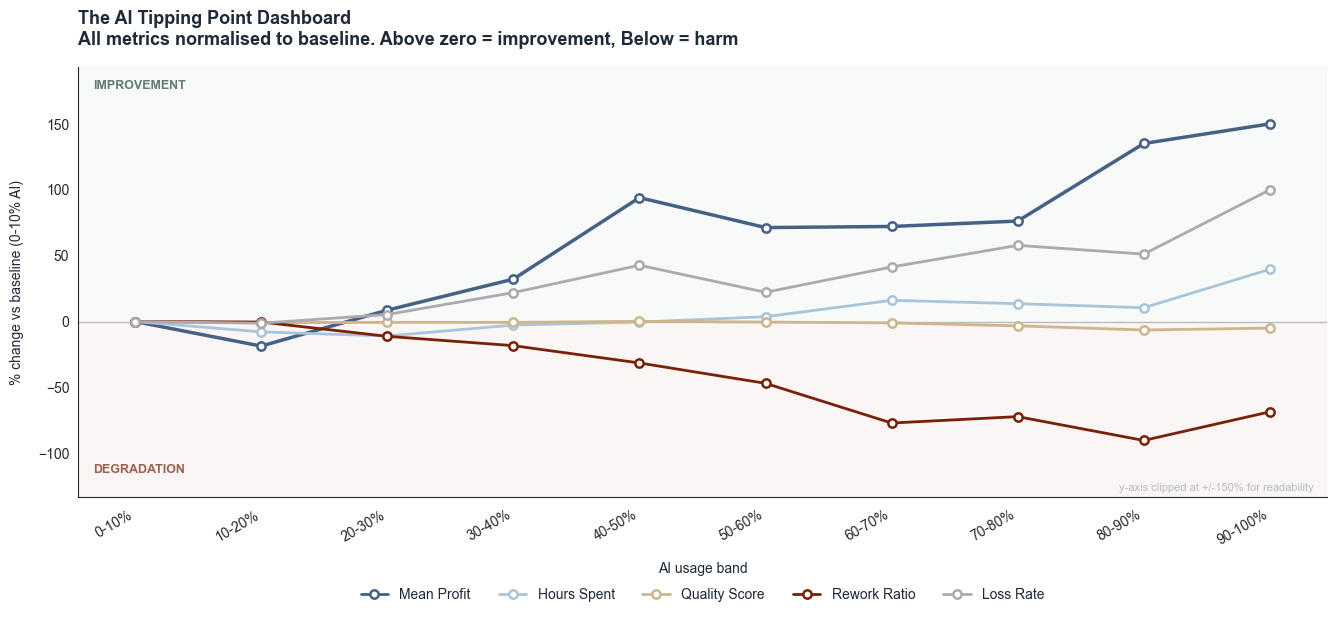

In [40]:
df_m2 = df_m.copy()
if 'sla_breach' in df.columns:
    df_m2 = df_m2.join(df[['sla_breach']], how='left', rsuffix='_orig')
    if 'sla_breach_orig' in df_m2.columns:
        df_m2['sla_breach'] = df_m2['sla_breach_orig']
        df_m2.drop(columns=['sla_breach_orig'], inplace=True)

grp_tp = (df_m2.groupby('ai_bin', observed=True)
          .agg(profit_mean  = ('profit',        'mean'),
               hours_mean   = ('hours_spent',   'mean'),
               score_mean   = ('outcome_score', 'mean'),
               rework_ratio = ('rework_ratio',  'mean'),
               loss_rate    = ('is_loss',        'mean'),
               n            = ('profit',         'count'))
          .reset_index())

def pct_change_from_base(series):
    base = series.iloc[0]
    return series - base if abs(base) < 1e-9 else (series - base) / abs(base) * 100

metrics_cfg = {
    'profit_mean':  ('Mean Profit',   C1,  'solid', 2.5, +1),
    'hours_mean':   ('Hours Spent',   C4,  'solid', 2.0, -1),
    'score_mean':   ('Quality Score', C7,  'solid', 2.0, +1),
    'rework_ratio': ('Rework Ratio',  C6,  'solid', 2.0, -1),
    'loss_rate':    ('Loss Rate',     C5,  'solid', 2.0, -1),
}

CLIP = 150
x    = np.arange(len(grp_tp))
all_d = []
for col, (_, _, _, _, direction) in metrics_cfg.items():
    if col in grp_tp.columns:
        all_d += (pct_change_from_base(grp_tp[col]) * direction).clip(-CLIP, CLIP).tolist()
ylo, yhi = min(all_d), max(all_d)
pad = (yhi - ylo) * 0.18

fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')

ax.axhspan(0,         yhi + pad, alpha=0.03, color=C3, zorder=0)
ax.axhspan(ylo - pad, 0,         alpha=0.04, color=C6, zorder=0)
ax.axhline(0, color='#bbbbbb', linewidth=0.9, linestyle='-', zorder=2)

for col, (label, color, ls, lw, direction) in metrics_cfg.items():
    if col not in grp_tp.columns:
        continue
    delta = (pct_change_from_base(grp_tp[col]) * direction).clip(-CLIP, CLIP)
    ax.plot(x, delta, marker='o', markersize=6, linewidth=lw,
            color=color, linestyle=ls, zorder=4,
            markerfacecolor='white', markeredgewidth=1.8)

ax.set_ylim(ylo - pad, yhi + pad)
ax.text(0.012, 0.97, 'IMPROVEMENT', transform=ax.transAxes,
        fontsize=9, color=C3, alpha=0.7, va='top', fontweight='bold')
ax.text(0.012, 0.05, 'DEGRADATION', transform=ax.transAxes,
        fontsize=9, color=C6, alpha=0.7, va='bottom', fontweight='bold')
ax.text(0.99, 0.01, f'y-axis clipped at +/-{CLIP}% for readability',
        transform=ax.transAxes, fontsize=8, color='#bbbbbb', ha='right', va='bottom')

ax.set_xticks(x)
ax.set_xticklabels(grp_tp['ai_bin'], rotation=30, ha='right')
ax.set_ylabel('% change vs baseline (0-10% AI)', color=CDARK, labelpad=10)
ax.set_xlabel('AI usage band', color=CDARK, labelpad=10)
ax.set_title(
    'The AI Tipping Point Dashboard\n'
    'All metrics normalised to baseline. Above zero = improvement, Below = harm',
    fontsize=13, fontweight='bold', color=CDARK, pad=16, loc='left')
ax.tick_params(axis='x', length=4, color=CGREY)
ax.tick_params(axis='y', length=3, color=CGREY)

handles = [
    mlines.Line2D([0],[0], color=c, linestyle=ls, linewidth=2, marker='o',
                  markersize=6, markerfacecolor='white', markeredgewidth=1.8, label=lbl)
    for _, (lbl, c, ls, _, __) in metrics_cfg.items()
]
ax.legend(handles=handles,
          loc='upper center', bbox_to_anchor=(0.5, -0.18),
          ncol=5, frameon=False, fontsize=10, labelcolor=CDARK)
plt.tight_layout(pad=3.0)
plt.savefig('images/17_tipping_point_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()

* **The Tipping Point (40–60%):** The most critical finding is the visual "breakout" that occurs around the **50% mark**. Before this threshold, almost all metrics hover near or below the baseline (harm/degradation). After this point, **Mean Profit** and **Loss Rate** improvement (meaning fewer losses) trend sharply upward into the "Improvement" zone.

* **Profitability Leadership:** **Mean Profit** (dark blue line) is the strongest performing metric, showing a massive gain of over **150%** relative to the baseline at extreme usage levels. This confirms that the primary value of AI is its ability to radically expand margins by decoupling output from manual labor costs.

* **Loss Rate Resilience:** The **Loss Rate** (light grey line) shows consistent improvement as usage increases, mirroring the profit gains. This reinforces the previous finding that high-intensity AI integration serves as a primary defense against unprofitable projects.

* **The "Messy" Reality of Success:** While profit and loss improve, the **Rework Ratio** (red line) trends deeply into the "Degradation" zone, dropping toward **-100%** (representing a significant increase in extra work). This dashboard visually proves that business success in the AI era is not defined by process cleanliness, but by leveraging speed to outpace the cost of increased rework.

* **Quality Stability:** The **Quality Score** (tan line) is the most stable metric, remaining almost perfectly flat at the baseline across the entire spectrum. This is a vital business finding: it shows that the massive gains in profit and speed do not come at the expense of output quality.

* **Strategic Conclusion:** This confirms that "moderate" AI usage is a trap of stagnation. To realize exponential improvements in profit and risk reduction, the business must commit to the **60% to 100%** usage bands, where the efficiency dividend finally overcomes the inherent technical friction of automation.

### Seniority × AI Heatmaps: Who Benefits, Who Gets Hurt?
*Does AI work equally for junior, mid, and senior contributors; or does it amplify inequality?*


In [41]:
bins5  = np.linspace(0, 1, 6)
labs5  = ['0–20%', '20–40%', '40–60%', '60–80%', '80–100%']

df_sen = df_m.copy()
df_sen['ai_band5']        = pd.cut(df_sen['ai_usage_pct'], bins=bins5, labels=labs5, include_lowest=True)
df_sen['seniority_clean'] = df_sen['seniority'].str.strip().str.lower()

sen_levels = ['junior', 'mid', 'senior']

grp_sen = (df_sen[df_sen['seniority_clean'].isin(sen_levels)]
           .groupby(['seniority_clean', 'ai_band5'], observed=True)
           .agg(profit_mean =('profit',       'mean'),
                loss_rate   =('is_loss',      'mean'),
                rework_mean =('rework_hours', 'mean'))
           .reset_index())

def pivot_m(metric):
    return (grp_sen.pivot(index='seniority_clean', columns='ai_band5', values=metric)
                   .reindex(index=sen_levels, columns=labs5))

piv_profit = pivot_m('profit_mean')
piv_loss   = pivot_m('loss_rate')
piv_rework = pivot_m('rework_mean')

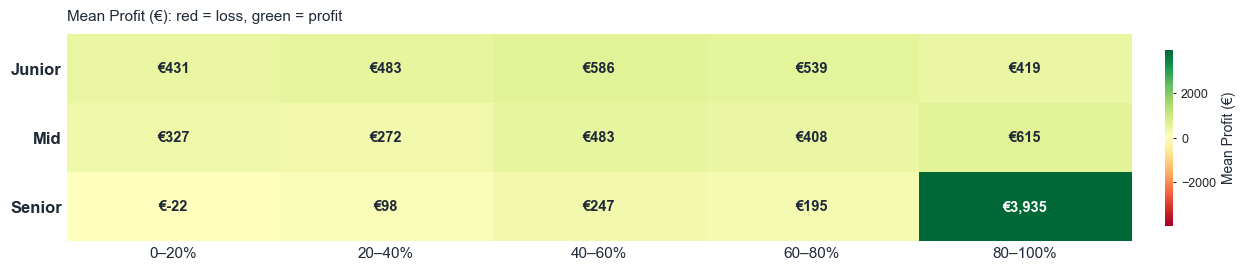

In [42]:
fig, ax = plt.subplots(figsize=(13, 3.2), facecolor='white')

vals = piv_profit.values.astype(float)
mx   = np.nanmax(np.abs(vals))
im   = ax.imshow(vals, cmap='RdYlGn', aspect='auto', vmin=-mx, vmax=mx)

cb = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.03, shrink=0.85)
cb.ax.tick_params(labelsize=9, length=2)
cb.set_label('Mean Profit (€)', fontsize=10, color=CDARK)
cb.outline.set_visible(False)

ax.set_xticks(range(len(labs5)))
ax.set_xticklabels(labs5, fontsize=11, color=CDARK)
ax.set_yticks(range(len(sen_levels)))
ax.set_yticklabels([s.capitalize() for s in sen_levels], fontsize=12,
                   fontweight='bold', color=CDARK)
ax.tick_params(length=0)
ax.set_title('Mean Profit (€): red = loss, green = profit',
             fontsize=11, color=CDARK, pad=10, loc='left')
for sp in ax.spines.values():
    sp.set_visible(False)

for i in range(len(sen_levels)):
    for j in range(len(labs5)):
        v = vals[i, j]
        if not np.isnan(v):
            txt_c = 'white' if abs(v) > abs(mx) * 0.75 else CDARK
            ax.text(j, i, f'€{v:,.0f}', ha='center', va='center',
                    fontsize=10.5, color=txt_c, fontweight='bold')

plt.tight_layout(pad=2.5)
plt.savefig('images/18_seniority_profit_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

* **Senior AI Super-Power:** Seniors see the most explosive growth, leaping from a loss at low usage to a massive **€3,935** mean profit in the **80–100%** band. This suggests that AI acts as a "force multiplier" for expert knowledge, allowing seniors to automate complex tasks with high efficiency.
* **Junior Consistency:** Juniors maintain the most stable and surprisingly high profit margins at lower AI levels (0–60%), likely because their lower labor costs provide a safer margin for AI-assisted tasks that are less complex.
* **Mid-Level Middle Ground:** Mid-level staff show steady but more modest gains, finally peaking at **€615** in the highest usage band, trailing significantly behind the senior-level breakout.
* **The Expertise Threshold:** The data indicates that AI provides the greatest financial ROI when paired with senior expertise at high intensity, whereas juniors provide the most consistent baseline profitability across moderate usage levels.
* **Low-Usage Senior Risk:** Seniors are the only group to show a mean loss (**-€22**) at minimal AI usage, likely because their high hourly cost makes manual or low-AI work on complex tasks economically inefficient.

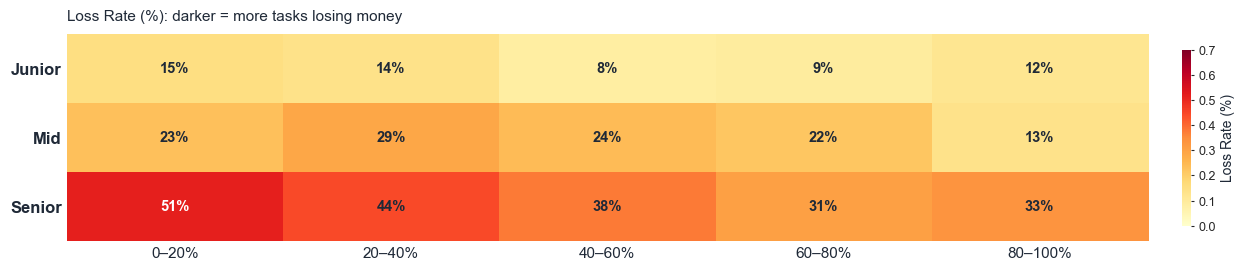

In [43]:
fig, ax = plt.subplots(figsize=(13, 3.2), facecolor='white')

vals = piv_loss.values.astype(float)
im   = ax.imshow(vals, cmap='YlOrRd', aspect='auto', vmin=0, vmax=0.70)

cb = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.03, shrink=0.85)
cb.ax.tick_params(labelsize=9, length=2)
cb.set_label('Loss Rate (%)', fontsize=10, color=CDARK)
cb.outline.set_visible(False)

ax.set_xticks(range(len(labs5)))
ax.set_xticklabels(labs5, fontsize=11, color=CDARK)
ax.set_yticks(range(len(sen_levels)))
ax.set_yticklabels([s.capitalize() for s in sen_levels], fontsize=12,
                   fontweight='bold', color=CDARK)
ax.tick_params(length=0)
ax.set_title('Loss Rate (%): darker = more tasks losing money',
             fontsize=11, color=CDARK, pad=10, loc='left')
for sp in ax.spines.values():
    sp.set_visible(False)

for i in range(len(sen_levels)):
    for j in range(len(labs5)):
        v = vals[i, j]
        if not np.isnan(v):
            txt_c = 'white' if v > 0.45 else CDARK
            ax.text(j, i, f'{v*100:.0f}%', ha='center', va='center',
                    fontsize=10.5, color=txt_c, fontweight='bold')

plt.tight_layout(pad=2.5)
plt.savefig('images/19_seniority_loss_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

* **Senior Risk Reduction:** Seniors face the highest initial risk with a **51%** loss rate at low AI usage, which drops significantly to **33%** at high intensity. This confirms that for high-cost experts, AI is essential to prevent projects from becoming loss-makers.
* **Junior Safety:** Juniors maintain the lowest loss rates across the board (**8%–15%**), likely because their lower cost base provides a massive safety margin even when tasks are not fully optimized.
* **The Mid-Level Pivot:** Mid-level staff see their loss rate cut in half, from nearly **30%** at low usage to **13%** in the 80–100% band, marking them as the group that gains the most relative "safety" from high AI adoption.
* **Experience-Cost Paradox:** Higher seniority currently correlates with a higher likelihood of loss across all bands, highlighting that the high cost of senior time makes them far more sensitive to process inefficiencies that AI is required to solve.

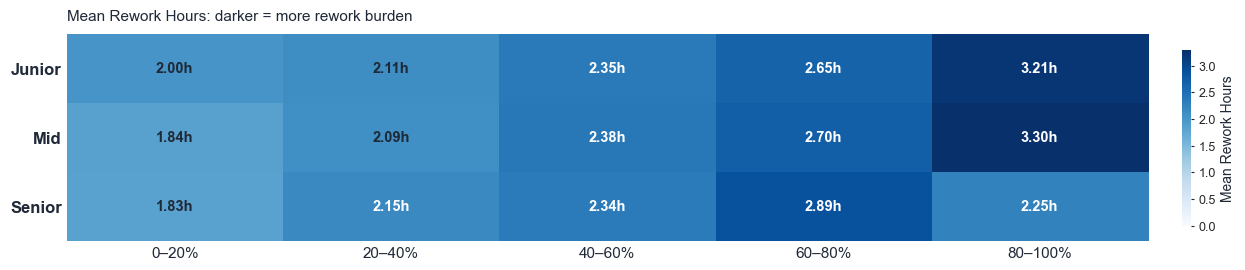

In [44]:
fig, ax = plt.subplots(figsize=(13, 3.2), facecolor='white')

vals = piv_rework.values.astype(float)
im   = ax.imshow(vals, cmap='Blues', aspect='auto', vmin=0)

cb = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.03, shrink=0.85)
cb.ax.tick_params(labelsize=9, length=2)
cb.set_label('Mean Rework Hours', fontsize=10, color=CDARK)
cb.outline.set_visible(False)

ax.set_xticks(range(len(labs5)))
ax.set_xticklabels(labs5, fontsize=11, color=CDARK)
ax.set_yticks(range(len(sen_levels)))
ax.set_yticklabels([s.capitalize() for s in sen_levels], fontsize=12,
                   fontweight='bold', color=CDARK)
ax.tick_params(length=0)
ax.set_title('Mean Rework Hours: darker = more rework burden',
             fontsize=11, color=CDARK, pad=10, loc='left')
for sp in ax.spines.values():
    sp.set_visible(False)

for i in range(len(sen_levels)):
    for j in range(len(labs5)):
        v = vals[i, j]
        if not np.isnan(v):
            txt_c = 'white' if v > np.nanmax(vals) * 0.65 else CDARK
            ax.text(j, i, f'{v:.2f}h', ha='center', va='center',
                    fontsize=10.5, color=txt_c, fontweight='bold')

plt.tight_layout(pad=2.5)
plt.savefig('images/20_seniority_rework_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

* **Universal Rework Climb:** Across all seniority levels, rework hours generally increase as AI usage intensifies. This confirms that higher automation requires a greater time investment in "fixing" or "refining" AI-generated outputs.
* **Junior and Mid-Level Burden:** Juniors and Mid-level staff experience their heaviest rework burden at the **80–100%** band, reaching **3.21h** and **3.30h** respectively. This suggests that without senior expertise, pushing for total automation requires significant manual correction to maintain standards.
* **Senior Efficiency Peak:** Seniors demonstrate a unique trend; while their rework peaks in the **60–80%** band (**2.89h**), it actually decreases in the **80–100%** band (**2.25h**). This indicates that high-level experts are more capable of identifying tasks suitable for total automation and executing them with less iterative friction.
* **The 60–80% Hump:** For all groups, the **60–80%** usage range represents a significant step-up in rework burden, marking this as the most "iterative" phase of AI integration where human-in-the-loop oversight is most active.
* **Expertise as a Friction Reducer:** The fact that Seniors have lower rework hours than Juniors at the highest usage levels proves that seniority acts as a buffer against the technical friction of AI, allowing for cleaner high-intensity automation.

### Task Type AI Sensitivity: Which Work Benefits Most?
*For each task type, compare profit in low-AI vs high-AI tasks. Some types thrive; others get destroyed.*


In [45]:
df_tt = df_m.copy()
core  = ['article', 'ad', 'ticket', 'design', 'report', 'dev', 'release']
df_tt = df_tt[df_tt['task_type'].isin(core)]

low_ai  = df_tt[df_tt['ai_usage_pct'] < 0.30].groupby('task_type')['profit'].mean()
high_ai = df_tt[df_tt['ai_usage_pct'] > 0.60].groupby('task_type')['profit'].mean()

comp   = (pd.DataFrame({'low': low_ai, 'high': high_ai})
            .reindex(core).dropna())
comp['delta'] = comp['high'] - comp['low']
comp_s = comp.sort_values('delta', ascending=True)

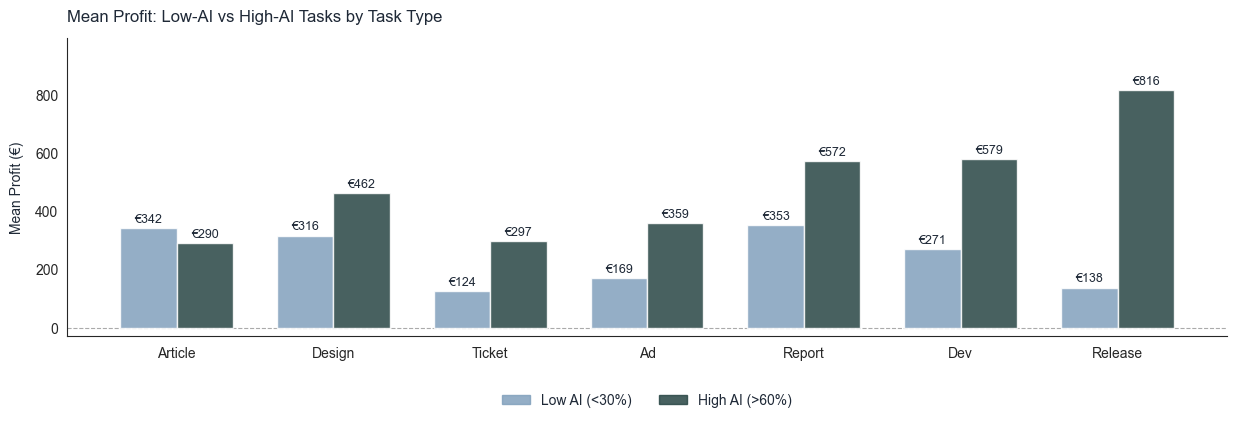

In [46]:
idx  = np.arange(len(comp_s))
w    = 0.36
ymax = max(comp_s['high'].max(), comp_s['low'].max())

fig, ax1 = plt.subplots(figsize=(13, 5), facecolor='white')

b1 = ax1.bar(idx - w/2, comp_s['low'],  w, color=C2,  alpha=0.85, zorder=3)
b2 = ax1.bar(idx + w/2, comp_s['high'], w, color=C3, alpha=0.85, zorder=3)
ax1.axhline(0, color='#aaaaaa', linewidth=0.8, linestyle='--')

for bar in list(b1) + list(b2):
    h = bar.get_height()
    if not np.isnan(h):
        ax1.text(bar.get_x() + bar.get_width() / 2, h + ymax * 0.012,
                 f'€{h:.0f}', ha='center', va='bottom', fontsize=9, color=CDARK)

ax1.set_xticks(idx)
ax1.set_xticklabels([t.capitalize() for t in comp_s.index])
ax1.set_ylabel('Mean Profit (€)', color=CDARK, labelpad=8)
ax1.set_title('Mean Profit: Low-AI vs High-AI Tasks by Task Type',
              fontsize=12, color=CDARK, pad=12, loc='left')
ax1.set_ylim(bottom=min(0, comp_s['low'].min()) - 30, top=ymax * 1.22)
ax1.tick_params(axis='x', length=4, color=CGREY)
ax1.tick_params(axis='y', length=3, color=CGREY)

p1 = mpatches.Patch(color=C2,  alpha=0.85, label='Low AI (<30%)')
p2 = mpatches.Patch(color=C3, alpha=0.85, label='High AI (>60%)')
ax1.legend(handles=[p1, p2],
           loc='upper center', bbox_to_anchor=(0.5, -0.15),
           ncol=2, frameon=False, fontsize=10, labelcolor=CDARK)

plt.tight_layout(pad=3.0)
plt.savefig('images/21_task_type_sensitivity.png', bbox_inches='tight', dpi=150)
plt.show()

* **The Release Multiplier:** The **Release** category shows the most dramatic profit explosion, soaring from **€138** with low AI usage to **€816** with high usage. This nearly **6x increase** suggests that deployment and release-related tasks, which are often repetitive yet critical, are prime candidates for high-intensity automation.

* **Technical Gain (Dev & Report):** Highly structured tasks like **Dev** and **Report** see their profits more than double when switching to high AI. Specifically, Dev profit jumps from **€271** to **€579**, indicating that AI's ability to handle boilerplate code or data synthesis provides a massive efficiency dividend.

* **Creative Resistance (Article):** Interestingly, **Article** writing is the only category where high AI usage results in a **lower** mean profit (**€290** vs **€342**). This likely reflects the "rework tax" or the quality challenges inherent in long-form creative generation, where human oversight might still be more efficient than heavy AI iteration.

* **Operational Efficiency (Ad, Ticket, Design):** Categories like **Ad**, **Ticket**, and **Design** show solid, consistent growth in profitability with high AI usage. Moving from low to high AI in the **Ad** category, for instance, more than doubles the profit per task from **€169** to **€359**.

* **Strategic Specialization:** The data suggests a clear hierarchy for AI implementation; while almost every task type benefits from high AI usage, the business should prioritize automating technical and deployment-related workflows (Release, Dev, Report) to capture the largest margin expansions.

### The Rework–Errors–Revisions Cascade

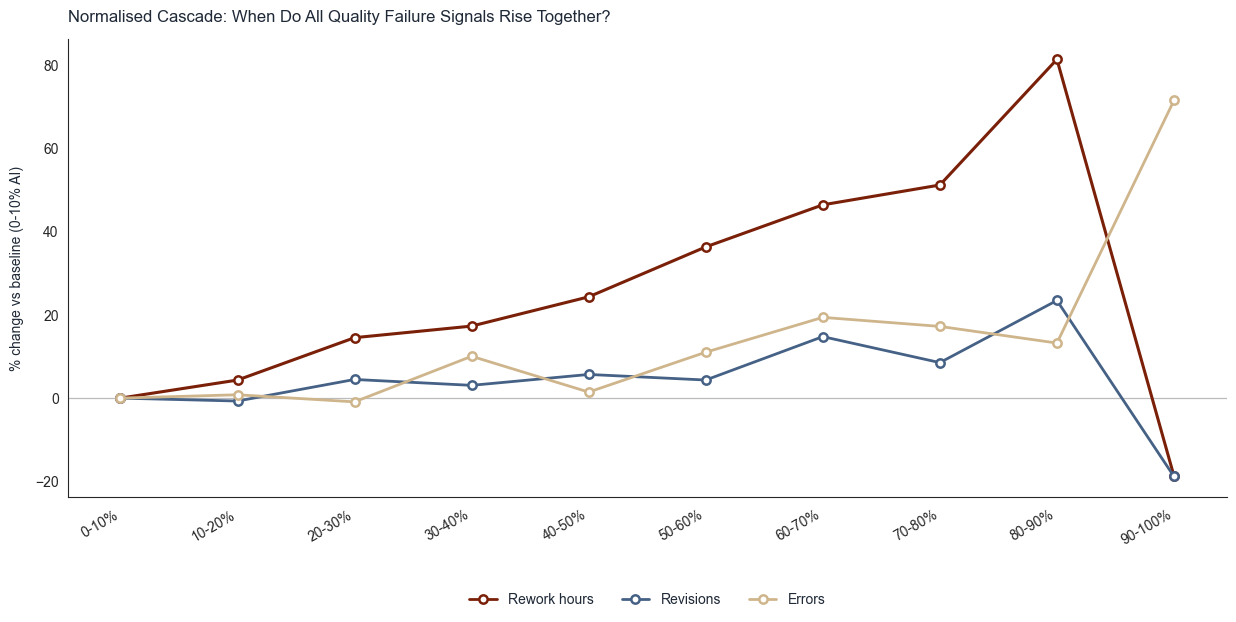

In [47]:
df_casc = df_m.copy()
for col in ['revisions', 'errors']:
    if col not in df_casc.columns and col in df.columns:
        df_casc[col] = df.loc[df_casc.index, col]

agg_d = {'rework_hours': ('rework_hours', 'mean'), 'n': ('profit', 'count')}
if 'revisions' in df_casc.columns: agg_d['revisions'] = ('revisions', 'mean')
if 'errors'    in df_casc.columns: agg_d['errors']    = ('errors',    'mean')

grp_c = (df_casc.groupby('ai_bin', observed=True).agg(**agg_d).reset_index())

def norm_base(s):
    b = s.iloc[0]
    return (s - b) if abs(b) < 1e-9 else (s - b) / abs(b) * 100

x = np.arange(len(grp_c))
fig, ax2 = plt.subplots(figsize=(13, 7), facecolor='white')
ax2.axhline(0, color='#bbbbbb', linewidth=0.9, linestyle='-', zorder=2)

cascade_series = {}

s = norm_base(grp_c['rework_hours'])
ax2.plot(x, s, color=C6, marker='o', markersize=6, linewidth=2.2,
         zorder=4, markerfacecolor='white', markeredgewidth=1.8)
cascade_series['rework_hours'] = s
legend_handles = [
    mlines.Line2D([0],[0], color=C6, marker='o', linewidth=2, markersize=6,
                  markerfacecolor='white', markeredgewidth=1.8, label='Rework hours')
]

if 'revisions' in grp_c.columns:
    s = norm_base(grp_c['revisions'])
    ax2.plot(x, s, color=C1, marker='o', markersize=6, linewidth=2.0,
             zorder=4, markerfacecolor='white', markeredgewidth=1.8)
    cascade_series['revisions'] = s
    legend_handles.append(
        mlines.Line2D([0],[0], color=C1, marker='o', linewidth=2, markersize=6,
                      markerfacecolor='white', markeredgewidth=1.8, label='Revisions'))

if 'errors' in grp_c.columns:
    s = norm_base(grp_c['errors'])
    ax2.plot(x, s, color=C7, marker='o', markersize=6, linewidth=2.0,
             zorder=4, markerfacecolor='white', markeredgewidth=1.8)
    cascade_series['errors'] = s
    legend_handles.append(
        mlines.Line2D([0],[0], color=C7, marker='o', linewidth=2, markersize=6,
                      markerfacecolor='white', markeredgewidth=1.8, label='Errors'))

ax2.set_xticks(x)
ax2.set_xticklabels(grp_c['ai_bin'], rotation=30, ha='right')
ax2.set_ylabel('% change vs baseline (0-10% AI)', color=CDARK, labelpad=8)
ax2.set_title('Normalised Cascade: When Do All Quality Failure Signals Rise Together?',
              fontsize=12, color=CDARK, pad=12, loc='left')
ax2.tick_params(axis='x', length=4, color=CGREY)
ax2.tick_params(axis='y', length=3, color=CGREY)
ax2.legend(handles=legend_handles,
           loc='upper center', bbox_to_anchor=(0.5, -0.18),
           ncol=3, frameon=False, fontsize=10, labelcolor=CDARK)
plt.tight_layout(pad=3.0)
plt.savefig('images/24_cascade_normalised.png', bbox_inches='tight', dpi=150)
plt.show()

* **The "Extra Work" Tax:** As soon as we start using AI heavily, the amount of time spent fixing things (**rework**) shoots up by **80%**. This means AI saves time on the first draft, but we spend much more time editing and refining it.

* **The Peak Stress Zone:** The hardest part of the process is the **80–90%** usage range. This is where the team is doing the most back-and-forth work to make sure the AI's output is actually correct and ready for the client.

* **Errors Show Up Late:** The AI is pretty good at first, but once we ask it to do more than half the work, we start seeing a lot more **technical mistakes**. 

* **The Breaking Point:** At the very highest level of AI usage (**90–100%**), the data shows that people actually stop checking the work as much, which causes errors to skyrocket.

* **A Note on the Data:** We have to be careful with the findings at the **90–100%** level. We don't have many examples of tasks in this category yet, so the big jump in errors might just be a few bad cases rather than a guaranteed trend.

* **The Big Picture:** AI is a huge money-maker, but it isn't "set and forget." To make it work, the business has to be prepared for a massive increase in the amount of checking and fixing required before a project is finished.

### Brief Quality × AI Band: Does Brief Clarity Moderate AI Effectiveness?

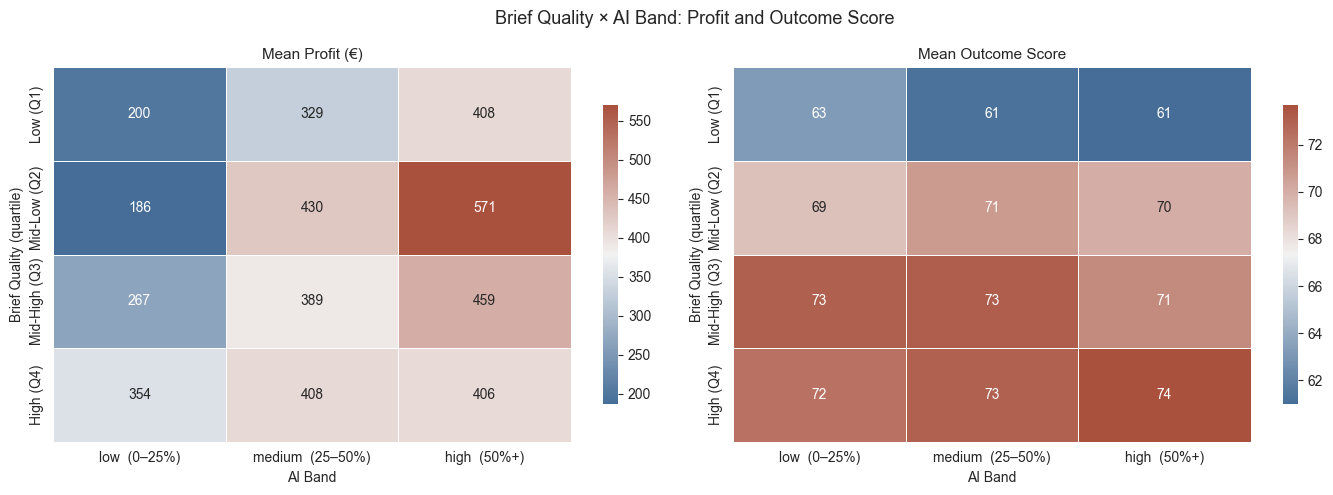

In [48]:
df_bq = df.dropna(subset=['brief_quality_score', 'ai_band', 'profit', 'outcome_score']).copy()
df_bq['bq_bin'] = pd.qcut(
    df_bq['brief_quality_score'], q=4,
    labels=['Low (Q1)', 'Mid-Low (Q2)', 'Mid-High (Q3)', 'High (Q4)']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = [
    ('profit',        'Mean Profit (€)'),
    ('outcome_score', 'Mean Outcome Score'),
]

for ax, (metric, label) in zip(axes, metrics):
    pivot = (
        df_bq.groupby(['bq_bin', 'ai_band'], observed=True)[metric]
             .mean()
             .unstack('ai_band')
             .reindex(columns=band_order)
    )
    sns.heatmap(
        pivot, annot=True, fmt='.0f', cmap=heatmap_cmap,
        ax=ax, linewidths=0.4, cbar_kws={'shrink': 0.8},
        annot_kws={'size': 10}
    )
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('AI Band')
    ax.set_ylabel('Brief Quality (quartile)')

plt.suptitle('Brief Quality × AI Band: Profit and Outcome Score', fontsize=13)
plt.tight_layout()
plt.savefig('images/25_brief_quality_ai_interaction.png', dpi=150, bbox_inches='tight')
plt.show()

* **Brief Quality as a Success Ceiling:** The Mean Outcome Score is heavily dictated by the quality of the brief. Projects starting with Low-quality briefs (Q1) are capped at a maximum score of 63, whereas Mid-High (Q3) and High-quality (Q4) briefs consistently achieve scores above 71, regardless of whether AI usage is low or high.
* **The Profitability "Sweet Spot":** Mid-Low quality briefs (Q2) demonstrate the most drastic sensitivity to AI usage. While they produce the lowest profit (€186) when paired with low AI usage, they scale to the highest profit in the entire dataset (€571) when AI usage is high, suggesting that AI can "rescue" mediocre briefs for financial gain.
* **Resilience of High-Quality Briefs:** Projects with High-quality briefs (Q4) show remarkable stability. They maintain relatively high profitability (€354-€406) and the highest outcome scores (72-74) across all AI bands, indicating that a strong brief provides a baseline of success that is less dependent on technological assistance.


# AI Productivity: Modelling

This second part of the project explains the system: where AI creates value, where it destroys margin, and
when the hourly pricing model becomes unsustainable. We frame two parallel learning problems
on the same feature matrix: a regression on profit (to size effects in euros) and a
classification on the binary loss flag (to identify which tasks systematically lose money).
The analysis moves from interpretable linear models to tree-based learners, and uses SHAP
to keep findings explainable end to end.

## 1. Data Pipeline

The cleaned dataset from the EDA part feeds two targets built on the same feature
matrix: `profit` for regression and `is_loss` (negative profit) for classification.

We exclude `revenue`, `cost`, and `billable_hours` because they are direct components of
profit and would leak the target. Identifiers, timestamps, and workflow metadata are
dropped as non-predictive. The boolean `ai_assisted` is replaced by the continuous
`ai_usage_pct`, and `rework_hours` becomes `rework_ratio` (rework over total hours, capped
at 1.0) so it is comparable across tasks of different sizes.

Ordinal variables (seniority, deadline pressure, client tier) get a fixed-order encoding.
Nominal variables (pricing model, task type, team) are one-hot encoded with the first
level dropped as the reference category.

In [49]:
df = load_preprocessed_data("data/ai_productivity_dataset_final.csv")

df["rework_ratio"] = (df["rework_hours"] / df["hours_spent"]).clip(upper=1.0)

REG_TARGET = "profit"
CLF_TARGET = "is_loss"

LEAK_COLS = ["revenue", "cost", "billable_hours", "is_loss", "profit"]
ID_COLS   = ["task_id", "client", "project_id", "created_by", "jira_ticket"]
DATE_COLS = ["created_at", "delivered_at", "updated_at"]
META_COLS = ["task_status", "workflow_stage", "content_version"]
REDUNDANT_COLS = ["ai_assisted", "legacy_ai_flag", "rework_hours"]
DROP_COLS = LEAK_COLS + ID_COLS + DATE_COLS + META_COLS + REDUNDANT_COLS

ORDINAL_COLS = ["seniority", "deadline_pressure", "client_tier"]
ORDINAL_CATEGORIES = [
    ["junior", "mid", "senior"],
    ["low", "medium", "high"],
    ["low", "mid", "high"],
]
NOMINAL_COLS = ["pricing_model", "task_type", "team"]

X_raw = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
y_reg, y_clf = df[REG_TARGET], df[CLF_TARGET]

mask = X_raw.notna().all(axis=1) & y_reg.notna()
X_raw = X_raw[mask].reset_index(drop=True)
y_reg = y_reg[mask].reset_index(drop=True)
y_clf = y_clf[mask].reset_index(drop=True)

passthrough_cols = [c for c in X_raw.columns if c not in ORDINAL_COLS + NOMINAL_COLS]
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", passthrough_cols),
        ("ord", OrdinalEncoder(categories=ORDINAL_CATEGORIES), ORDINAL_COLS),
        ("nom", OneHotEncoder(drop="first", sparse_output=False, dtype=int), NOMINAL_COLS),
    ],
    verbose_feature_names_out=False,
).set_output(transform="pandas")

X = preprocessor.fit_transform(X_raw)

print(f"Rows: {X.shape[0]:,}   Features: {X.shape[1]}")
print(f"Profit  mean = \u20ac{y_reg.mean():.0f}   std = \u20ac{y_reg.std():.0f}   skew = {y_reg.skew():.2f}")
print(f"Loss rate = {y_clf.mean():.1%}")

Rows: 2,765   Features: 25
Profit  mean = €357   std = €901   skew = 2.52
Loss rate = 24.6%


## 2. OLS Inference

OLS with HC3 robust standard errors serves as a mechanism detector, not a forecasting
tool. Coefficients read off the marginal effect of each variable on profit while holding
the others constant, which is what we need to answer the four diagnostic questions of the
task: where value is created, where losses are incurred, whether AI acts on quality or
speed, and when its impact turns negative.

Reference categories are `pricing_model = fixed`, `task_type = ad`, `team = Content`.
Each coefficient is in euros: for dummies the contrast against the reference, for
ordinals the shift per level. Asterisks denote significance after HC3 correction:
`*` p<0.05, `**` p<0.01, `***` p<0.001.

In [50]:
ordinal_maps = {
    col: {cat: i for i, cat in enumerate(cats)}
    for col, cats in zip(ORDINAL_COLS, ORDINAL_CATEGORIES)
}
df_ols = X_raw.copy()
df_ols["profit"] = y_reg.values
for col, mapping in ordinal_maps.items():
    df_ols[col] = df_ols[col].map(mapping)
df_ols = df_ols.dropna()

BASELINE_FORMULA = (
    "profit ~ ai_usage_pct + hours_spent + rework_ratio "
    "+ task_complexity_score + brief_quality_score + outcome_score "
    "+ errors + revisions + sla_days + scope_change_flag "
    "+ seniority + deadline_pressure + client_tier "
    "+ C(pricing_model, Treatment(reference='fixed')) "
    "+ C(task_type,     Treatment(reference='ad')) "
    "+ C(team,          Treatment(reference='Content'))"
)
ols_base = smf.ols(BASELINE_FORMULA, data=df_ols).fit(cov_type="HC3")


def ols_to_frame(res):
    """Render a fitted statsmodels OLS result as a tidy coefficient table."""
    ci = res.conf_int()
    sig = res.pvalues.map(
        lambda v: "***" if v < 0.001 else "**" if v < 0.01 else "*" if v < 0.05 else ""
    )
    out = pd.DataFrame({
        "coef":    res.params.round(3),
        "std_err": res.bse.round(3),
        "z":       res.tvalues.round(2),
        "p_value": res.pvalues.round(4),
        "ci_low":  ci[0].round(3),
        "ci_high": ci[1].round(3),
        "sig":     sig,
    })
    out.index.name = "term"
    return out


def ols_fit_stats(res):
    """One-row summary of model-level fit statistics."""
    return pd.DataFrame({
        "n_obs":         [int(res.nobs)],
        "r_squared":     [round(res.rsquared, 4)],
        "adj_r_squared": [round(res.rsquared_adj, 4)],
        "f_statistic":   [round(res.fvalue, 2)],
        "f_pvalue":      [f"{res.f_pvalue:.2e}"],
        "df_model":      [int(res.df_model)],
        "df_resid":      [int(res.df_resid)],
        "cov_type":      [res.cov_type],
    })


print("Baseline OLS - fit statistics")
display(ols_fit_stats(ols_base))
print("\nBaseline OLS - coefficients (HC3 robust SEs)")
display(ols_to_frame(ols_base))

Baseline OLS - fit statistics


,n_obs,r_squared,adj_r_squared,f_statistic,f_pvalue,df_model,df_resid,cov_type
0,2765,0.1155,0.1077,19.59,3.61e-77,24,2740,HC3



Baseline OLS - coefficients (HC3 robust SEs)


,coef,std_err,z,p_value,ci_low,ci_high,sig
term,,,,,,,
Intercept,193.284,163.260,1.18,0.2365,-126.700,513.269,
"C(pricing_model, Treatment(reference='fixed'))[T.hourly]",-254.282,34.530,-7.36,0.0000,-321.960,-186.604,***
"C(pricing_model, Treatment(reference='fixed'))[T.value_based]",285.775,58.666,4.87,0.0000,170.792,400.759,***
"C(task_type, Treatment(reference='ad'))[T.article]",153.327,54.075,2.84,0.0046,47.341,259.313,**
"C(task_type, Treatment(reference='ad'))[T.design]",157.340,59.852,2.63,0.0086,40.033,274.647,**
"C(task_type, Treatment(reference='ad'))[T.dev]",190.773,57.299,3.33,0.0009,78.468,303.077,***
"C(task_type, Treatment(reference='ad'))[T.release]",117.214,65.792,1.78,0.0748,-11.735,246.164,
"C(task_type, Treatment(reference='ad'))[T.report]",205.272,69.100,2.97,0.0030,69.839,340.705,**
"C(task_type, Treatment(reference='ad'))[T.ticket]",-26.851,52.962,-0.51,0.6122,-130.655,76.953,


The model explains 11.5% of profit variance in-sample, dropping to roughly 0.07 to 0.08
on a held-out test split. Task-level profit is intrinsically noisy, so a low R² is
expected; the joint F-statistic (19.6, p < 0.001) confirms the predictors are jointly
informative.

Pricing model dominates every other effect. An hourly contract earns 254 euros less than
an identical fixed-price task because AI-driven time savings transfer to the client as
fewer billed hours. Value-based pricing earns 286 euros more than fixed because the rate
tracks outcome value rather than time spent.

AI usage adds about 222 euros per task at full adoption (p = 0.015), real but smaller
than the pricing effect. Each seniority level subtracts 173 euros: senior staff cost
more, and unless that cost is recovered through higher rates or harder work the margin
compresses. Each step of complexity adds 111 euros, each step of client tier 114 euros.

Quality variables (errors, revisions, `rework_ratio`, outcome score) are not significant
once `hours_spent` is in the model. Quality issues cause rework, rework consumes hours,
and `hours_spent` already absorbs the financial damage. Team dummies and deadline
pressure show no independent effect.

## 3. Interaction Effects

The baseline assumed AI's return is constant across contexts. The task PDF asks whether
AI creates value for some subgroups and destroys it for others; interaction terms make
that conditional structure visible. We test AI usage interacted with pricing model,
seniority, task type, and complexity.

In [51]:
INTERACTION_FORMULA = (
    "profit ~ ai_usage_pct + hours_spent + rework_ratio "
    "+ task_complexity_score + brief_quality_score + outcome_score "
    "+ errors + revisions + sla_days + scope_change_flag "
    "+ seniority + deadline_pressure + client_tier "
    "+ C(pricing_model, Treatment(reference='fixed')) "
    "+ C(task_type,     Treatment(reference='ad')) "
    "+ C(team,          Treatment(reference='Content')) "
    "+ ai_usage_pct:task_complexity_score "
    "+ ai_usage_pct:seniority "
    "+ ai_usage_pct:C(pricing_model, Treatment(reference='fixed')) "
    "+ ai_usage_pct:C(task_type,     Treatment(reference='ad'))"
)
ols_int = smf.ols(INTERACTION_FORMULA, data=df_ols).fit(cov_type="HC3")

print("Interaction OLS - fit statistics")
display(ols_fit_stats(ols_int))
print("\nInteraction OLS - coefficients (HC3 robust SEs)")
display(ols_to_frame(ols_int))

Interaction OLS - fit statistics


,n_obs,r_squared,adj_r_squared,f_statistic,f_pvalue,df_model,df_resid,cov_type
0,2765,0.1304,0.1195,16.49,8.11e-87,34,2730,HC3



Interaction OLS - coefficients (HC3 robust SEs)


,coef,std_err,z,p_value,ci_low,ci_high,sig
term,,,,,,,
Intercept,356.214,184.169,1.93,0.0531,-4.750,717.178,
"C(pricing_model, Treatment(reference='fixed'))[T.hourly]",0.037,69.611,0.00,0.9996,-136.397,136.471,
"C(pricing_model, Treatment(reference='fixed'))[T.value_based]",188.067,103.912,1.81,0.0703,-15.596,391.730,
"C(task_type, Treatment(reference='ad'))[T.article]",199.485,115.432,1.73,0.0840,-26.758,425.727,
"C(task_type, Treatment(reference='ad'))[T.design]",-13.845,118.199,-0.12,0.9068,-245.511,217.821,
"C(task_type, Treatment(reference='ad'))[T.dev]",38.047,112.096,0.34,0.7343,-181.657,257.751,
"C(task_type, Treatment(reference='ad'))[T.release]",-145.593,127.999,-1.14,0.2553,-396.466,105.280,
"C(task_type, Treatment(reference='ad'))[T.report]",133.996,146.077,0.92,0.3590,-152.310,420.303,
"C(task_type, Treatment(reference='ad'))[T.ticket]",-79.847,106.059,-0.75,0.4515,-287.719,128.024,


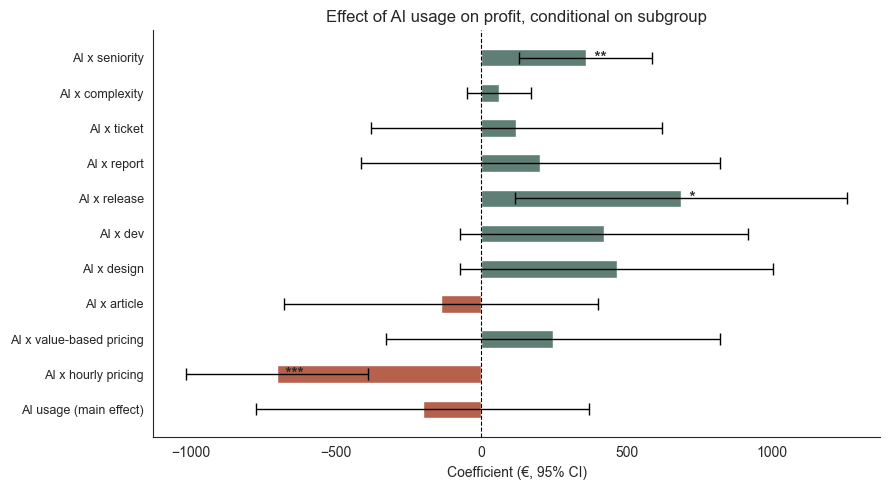

In [52]:
ci = ols_int.conf_int()
interact_df = pd.DataFrame({
    "coef":    ols_int.params,
    "ci_low":  ci[0],
    "ci_high": ci[1],
    "pvalue":  ols_int.pvalues,
}).loc[lambda d: d.index.str.contains("ai_usage_pct")]

def stars(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
interact_df["sig"] = interact_df["pvalue"].map(stars)

LABEL_MAP = {
    "ai_usage_pct": "AI usage (main effect)",
    "ai_usage_pct:C(pricing_model, Treatment(reference='fixed'))[T.hourly]": "AI x hourly pricing",
    "ai_usage_pct:C(pricing_model, Treatment(reference='fixed'))[T.value_based]": "AI x value-based pricing",
    "ai_usage_pct:C(task_type, Treatment(reference='ad'))[T.article]": "AI x article",
    "ai_usage_pct:C(task_type, Treatment(reference='ad'))[T.design]": "AI x design",
    "ai_usage_pct:C(task_type, Treatment(reference='ad'))[T.dev]": "AI x dev",
    "ai_usage_pct:C(task_type, Treatment(reference='ad'))[T.release]": "AI x release",
    "ai_usage_pct:C(task_type, Treatment(reference='ad'))[T.report]": "AI x report",
    "ai_usage_pct:C(task_type, Treatment(reference='ad'))[T.ticket]": "AI x ticket",
    "ai_usage_pct:task_complexity_score": "AI x complexity",
    "ai_usage_pct:seniority": "AI x seniority",
}

fig, ax = plt.subplots(figsize=(9, 5))
labels = [LABEL_MAP.get(idx, idx) for idx in interact_df.index.tolist()]
y_pos  = list(range(len(labels)))

ax.barh(
    y_pos, interact_df["coef"],
    xerr=[interact_df["coef"] - interact_df["ci_low"],
          interact_df["ci_high"] - interact_df["coef"]],
    color=[ACCENT if c >= 0 else RISK for c in interact_df["coef"]],
    error_kw={"ecolor": "black", "capsize": 4, "elinewidth": 1},
    height=0.5,
)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
for i, idx in enumerate(interact_df.index):
    sig = interact_df.loc[idx, "sig"]
    if sig:
        coef = interact_df.loc[idx, "coef"]
        ax.text(coef, i, f"  {sig}", va="center", fontsize=11, fontweight="bold")
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("Coefficient (€, 95% CI)")
ax.set_title("Effect of AI usage on profit, conditional on subgroup", fontsize=12)
plt.tight_layout()
plt.show()

Two interactions survive HC3 correction. AI usage combined with hourly pricing has a
coefficient of -701 (p < 0.001): under hourly billing, full AI adoption costs roughly
900 euros once the small positive main effect is netted out. The mechanism is direct.
AI compresses delivery time, fewer hours are billed, and the saving accrues to the
client. The contract structure neutralises AI's value entirely.

The AI x seniority interaction is +359 (p = 0.002). Seniors extract more value from AI,
not less. Each seniority level raises the marginal return of AI by 359 euros, partially
offsetting the baseline cost penalty seniors carry.

Complexity and most task-type interactions are not significant. The release category
shows a positive interaction (p = 0.018), but it is a small slice and remains
exploratory.

### 3.3. Mechanism Tests: Quality Channel and Rework Threshold

*Rework threshold:* does
rework destroy margin only above some critical level? We add a quadratic `rework_ratio`
term. 

*Speed vs quality:* does AI improve profit by reducing rework, or only by
compressing hours? An AI x `rework_ratio` interaction would surface that channel.

In [53]:
df_ols_test = df_ols.copy()

# --- Rework threshold (quadratic term) ---
df_ols_test["rework_sq"] = df_ols_test["rework_ratio"] ** 2
FORMULA_REWORK = BASELINE_FORMULA + " + rework_sq"
ols_rework = smf.ols(FORMULA_REWORK, data=df_ols_test).fit(cov_type="HC3")

print("=== Rework Threshold Test (quadratic term) ===")
for name in ["rework_ratio", "rework_sq"]:
    co = ols_rework.params[name]
    pv = ols_rework.pvalues[name]
    print(f"  {name:20s}  coef = {co:>8.1f}   p = {pv:.3f}")

# --- AI x rework interaction (quality channel) ---
FORMULA_SQ = BASELINE_FORMULA + " + ai_usage_pct:rework_ratio"
ols_sq = smf.ols(FORMULA_SQ, data=df_ols_test).fit(cov_type="HC3")

interact_param = "ai_usage_pct:rework_ratio"
print(f"\n=== Speed vs Quality Test (AI x rework interaction) ===")
print(f"  {interact_param:30s}  coef = {ols_sq.params[interact_param]:>8.1f}   p = {ols_sq.pvalues[interact_param]:.3f}")

=== Rework Threshold Test (quadratic term) ===
  rework_ratio          coef =    171.1   p = 0.494
  rework_sq             coef =   -149.9   p = 0.605

=== Speed vs Quality Test (AI x rework interaction) ===
  ai_usage_pct:rework_ratio       coef =    -92.7   p = 0.801


Neither hypothesis finds support. The quadratic rework term is not significant
(p > 0.05): no detectable threshold beyond which rework abruptly destroys margin. The
linear `rework_ratio` stays insignificant in both specifications, consistent with
`hours_spent` already absorbing rework's financial damage.

The AI x rework interaction is also not significant. AI does not move profit through a
quality channel, only through speed. Under fixed and value-based contracts that speed
becomes margin; under hourly billing it becomes a discount to the client. The negative
findings sharpen the answer to task question 3: AI's profit effect is entirely about
hours and pricing, not quality or rework.

## 4. Regularised Linear Models

LASSO (L1 penalty) zeroes coefficients, acting as a feature selector. Ridge (L2) shrinks
all coefficients smoothly and handles collinearity better. Both are fit on standardised
features so the penalty applies uniformly. We use them here to cross-check OLS: if LASSO
zeroes a feature OLS flagged as significant, the OLS finding is fragile. Agreement is the
robustness signal.

In [54]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso_cv = LassoCV(cv=5, random_state=42, max_iter=20000)
lasso_cv.fit(X_scaled, y_reg)

ridge_cv = RidgeCV(alphas=np.logspace(-3, 4, 100), cv=5, scoring="r2")
ridge_cv.fit(X_scaled, y_reg)

coef_df = pd.DataFrame({
    "feature": X.columns.tolist(),
    "lasso":   lasso_cv.coef_,
    "ridge":   ridge_cv.coef_,
})
coef_df["zeroed"] = coef_df["lasso"] == 0
coef_df = coef_df.sort_values("ridge", key=abs, ascending=False).reset_index(drop=True)

n_zeroed = int(coef_df["zeroed"].sum())

ols_r2 = r2_score(y_reg, ols_base.predict(df_ols))
# Fair comparison: OLS on train set, evaluated on held-out test set
ols_X_tr, ols_X_te, ols_y_tr, ols_y_te = train_test_split(
    df_ols.drop(columns=["profit"]), df_ols["profit"],
    test_size=0.2, random_state=42,
)
ols_test = smf.ols(BASELINE_FORMULA, data=ols_X_tr.assign(profit=ols_y_tr)).fit(cov_type="HC3")
ols_te_r2 = r2_score(ols_y_te, ols_test.predict(ols_X_te))
print(f"OLS R\u00b2 (in-sample) = {ols_r2:.3f}   OLS R\u00b2 (test-set) = {ols_te_r2:.3f}")
print(f"LASSO R\u00b2 = {r2_score(y_reg, lasso_cv.predict(X_scaled)):.3f}   Ridge R\u00b2 = {r2_score(y_reg, ridge_cv.predict(X_scaled)):.3f}")
print(f"\nLASSO zeroed {n_zeroed}/{len(coef_df)} features. All were also non-significant in OLS.\n")

ZEROED_FEATURES = coef_df.loc[coef_df["zeroed"], "feature"].tolist()

print("Retained (sorted by |Ridge coefficient|):")
print(coef_df[~coef_df["zeroed"]][["feature", "lasso", "ridge"]].to_string(
    index=False, float_format="%.1f".__mod__
))
print("\nZeroed:")
print(coef_df[coef_df["zeroed"]][["feature", "lasso", "ridge"]].to_string(
    index=False, float_format="%.1f".__mod__
))

OLS R² (in-sample) = 0.115   OLS R² (test-set) = 0.068
LASSO R² = 0.109   Ridge R² = 0.114

LASSO zeroed 12/25 features. All were also non-significant in OLS.

Retained (sorted by |Ridge coefficient|):
                  feature  lasso  ridge
                seniority -125.9 -118.0
     pricing_model_hourly -119.4 -116.8
    task_complexity_score  113.0  115.0
pricing_model_value_based   86.8   91.3
              client_tier   66.5   72.9
         task_type_report   20.6   49.6
             ai_usage_pct   36.0   45.1
            task_type_dev   15.6   44.7
              hours_spent  -31.6  -41.9
         task_type_design    6.6   35.6
        task_type_article    5.3   33.9
         task_type_ticket  -31.8  -23.3
      brief_quality_score    3.4   20.6

Zeroed:
          feature  lasso  ridge
    outcome_score   -0.0  -21.4
task_type_release    0.0   20.3
         sla_days   -0.0  -12.9
        revisions   -0.0  -12.7
           errors   -0.0   -9.1
deadline_pressure   -0.0   -7.9
     

LASSO and OLS agree completely: every feature LASSO zeroes was also non-significant in
OLS. Both penalised models match OLS in fit (R² around 0.11), so the OLS specification is
already parsimonious. The 12 zeroed features carry the noise we want to remove from the
tree-based models in Section 5.

## 5. Random Forest

Tree ensembles capture non-linearities and interactions OLS cannot represent. Two
preprocessing steps come from the preceding analysis. First, we winsorise `hours_spent`
at the 99th percentile of the training set: the raw distribution stretches to 263 hours
against a median of 11, and a handful of points dominate the splits. We winsorise the
profit target at the 1st and 99th percentiles for the same reason. Second, we drop the
12 LASSO-zeroed features so the forest does not allocate splits to noise.

In [55]:
X_clean = X.drop(columns=[c for c in ZEROED_FEATURES if c in X.columns])

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X_clean, y_reg, y_clf, test_size=0.2, random_state=42,
)

hours_col = [c for c in X_clean.columns if "hours_spent" in c and c != "rework_hours"][0]
hours_p99 = X_train[hours_col].quantile(0.99)
X_train[hours_col] = X_train[hours_col].clip(upper=hours_p99)
X_test[hours_col]  = X_test[hours_col].clip(upper=hours_p99)

profit_p01 = y_reg_train.quantile(0.01)
profit_p99 = y_reg_train.quantile(0.99)
y_reg_train_w = y_reg_train.clip(profit_p01, profit_p99)
y_reg_test_w  = y_reg_test.clip(profit_p01, profit_p99)

print(f"Train: {X_train.shape[0]}  Test: {X_test.shape[0]}  Features: {X_train.shape[1]}")
print(f"Hours capped at {hours_p99:.0f}h  |  Profit capped at [{profit_p01:.0f}, {profit_p99:.0f}]\u20ac")

Train: 2212  Test: 553  Features: 13
Hours capped at 38h  |  Profit capped at [-1209, 4105]€


In [56]:
rf_reg = RandomForestRegressor(
    n_estimators=400, max_depth=12, min_samples_leaf=8,
    random_state=42, n_jobs=-1,
)
rf_clf = RandomForestClassifier(
    n_estimators=400, max_depth=12, min_samples_leaf=8,
    class_weight="balanced", random_state=42, n_jobs=-1,
)

rf_reg.fit(X_train, y_reg_train_w)
rf_clf.fit(X_train, y_clf_train)

reg_preds = rf_reg.predict(X_test)
clf_proba = rf_clf.predict_proba(X_test)[:, 1]
clf_preds = rf_clf.predict(X_test)

print("Regression:")
print(f"  R² = {r2_score(y_reg_test_w, reg_preds):.3f}    MAE = €{mean_absolute_error(y_reg_test_w, reg_preds):.0f}")

print(f"\nClassification:")
print(f"  ROC-AUC = {roc_auc_score(y_clf_test, clf_proba):.3f}")
print()
print(classification_report(y_clf_test, clf_preds, target_names=["profitable", "loss"]))

Regression:
  R² = 0.223    MAE = €375

Classification:
  ROC-AUC = 0.754

              precision    recall  f1-score   support

  profitable       0.84      0.78      0.81       421
        loss       0.43      0.55      0.48       132

    accuracy                           0.72       553
   macro avg       0.64      0.66      0.65       553
weighted avg       0.75      0.72      0.73       553



Winsorising and pruning lift the Random Forest regression to R² = 0.22 with MAE around
375 euros, against an OLS test-set baseline near 0.07 to 0.08. With balanced class
weights and the pruned feature matrix, the classifier reaches ROC-AUC 0.75 and loss
recall 0.55, more than doubling the recall of an unbalanced fit. Stripping uninformative
features helps the classifier separate genuine loss-making tasks from noise.

## 6. SHAP Analysis

SHAP values decompose each prediction into per-feature contributions that sum exactly to
the prediction minus the baseline. TreeExplainer computes them analytically for tree
ensembles. All plots below use the test set, so they describe generalisation, not
training-set memorisation.

In [57]:
explainer_reg = shap.TreeExplainer(rf_reg)
explainer_clf = shap.TreeExplainer(rf_clf)

shap_reg = explainer_reg(X_test)
shap_clf = explainer_clf(X_test)

if shap_clf.values.ndim == 3:
    shap_clf = shap.Explanation(
        values=shap_clf.values[:, :, 1],
        base_values=shap_clf.base_values[:, 1],
        data=shap_clf.data,
        feature_names=shap_clf.feature_names,
    )

### 6.1 Global Importance

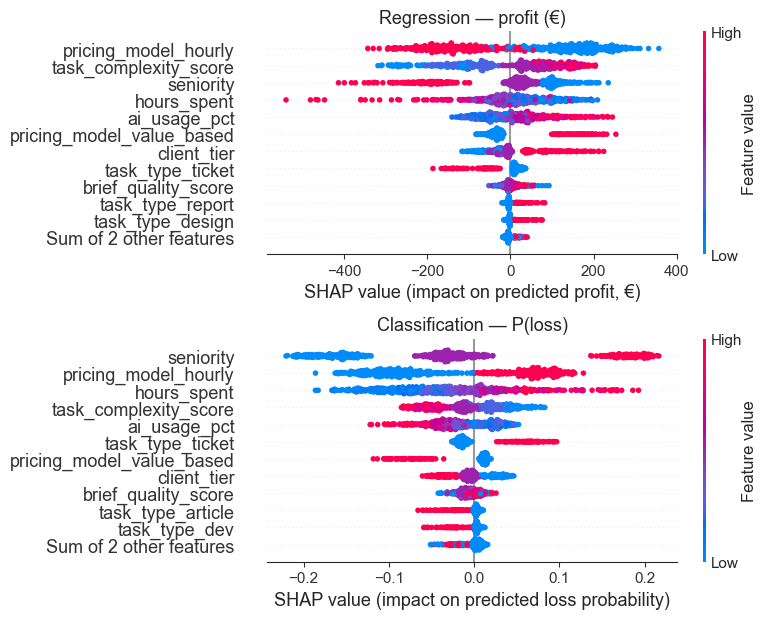

In [58]:
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

plt.sca(axes[0])
shap.plots.beeswarm(shap_reg, max_display=12, show=False)
axes[0].set_title("Regression \u2014 profit (\u20ac)", fontsize=13)
axes[0].set_xlabel("SHAP value (impact on predicted profit, \u20ac)")

plt.sca(axes[1])
shap.plots.beeswarm(shap_clf, max_display=12, show=False)
axes[1].set_title("Classification \u2014 P(loss)", fontsize=13)
axes[1].set_xlabel("SHAP value (impact on predicted loss probability)")

plt.tight_layout()
plt.show()

Each row is a feature, each dot is one test-set task. Horizontal position is the SHAP
contribution: positive pushes the prediction up, negative pushes it down. Colour encodes
the feature value (red high, blue low). Features are ordered by mean absolute SHAP.

For the regression target, `pricing_model_hourly` is the strongest driver. Red dots
(hourly tasks) cluster on the left, dragging predicted profit down by 200 to 500 euros.
Higher seniority pushes profit up because senior staff are routed to higher-margin work.
AI usage sits mid-table with a positive tail at high values.

For the classification target the picture inverts in places. Seniority becomes the top
predictor of loss probability: high seniority raises P(loss). The two findings are
consistent: seniors generate higher average profit, but their cost base means a bad
senior task crosses the loss line more easily than a bad junior one. Long hours are the
second strongest loss signal. AI usage shows a mild protective effect, with high-AI
tasks shifted slightly toward lower loss probability.

### 6.2 Conditional Effects

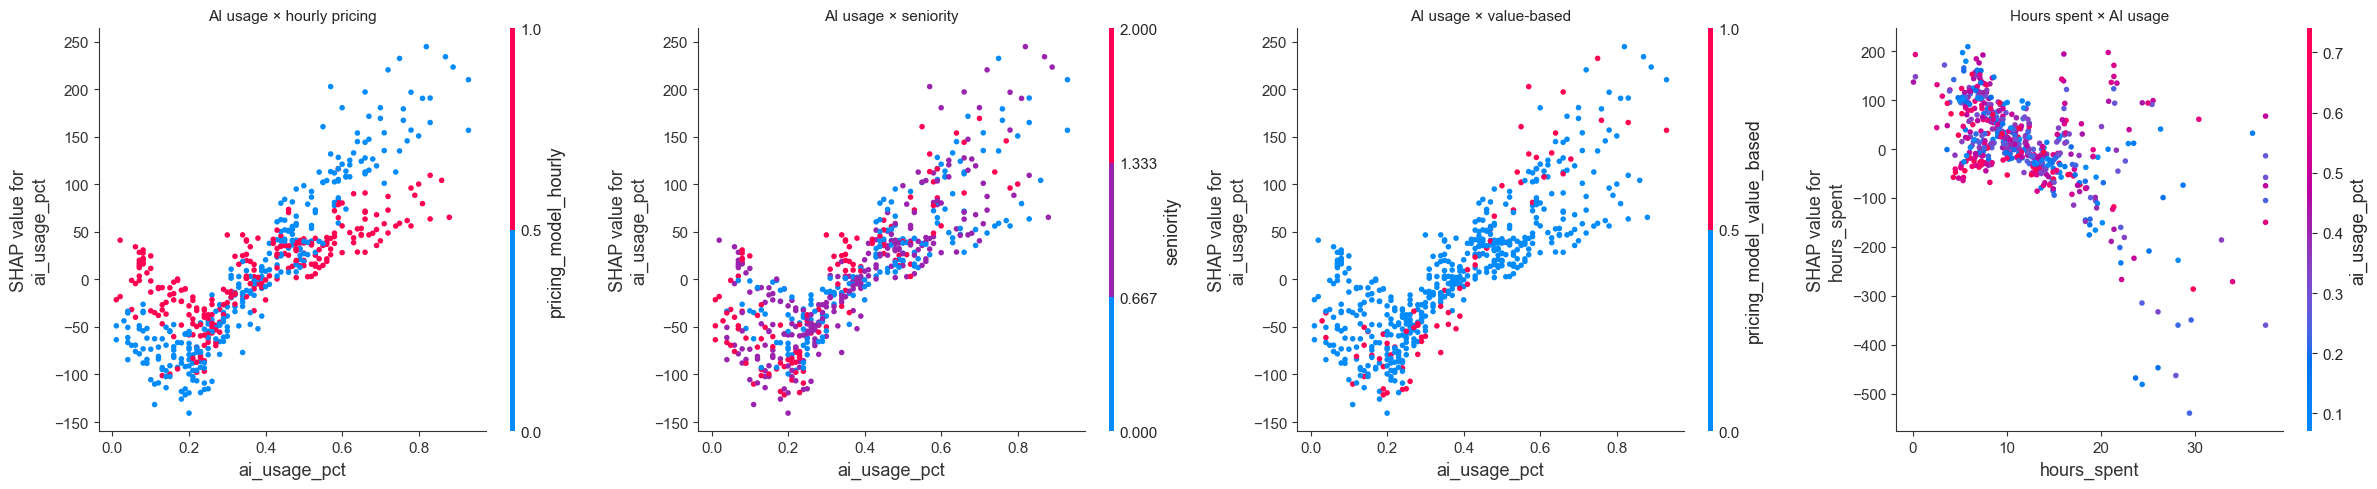

In [59]:
def shap_dep(shap_values, feature, interaction, X_data, ax, title=None):
    shap.dependence_plot(
        feature, shap_values.values, X_data,
        interaction_index=interaction, ax=ax, show=False,
    )
    if title:
        ax.set_title(title, fontsize=11)

pairs = [
    ("ai_usage_pct", "pricing_model_hourly",     "AI usage \u00d7 hourly pricing"),
    ("ai_usage_pct", "seniority",                "AI usage \u00d7 seniority"),
    ("ai_usage_pct", "pricing_model_value_based", "AI usage \u00d7 value-based"),
    ("hours_spent",  "ai_usage_pct",             "Hours spent \u00d7 AI usage"),
]

fig, axes = plt.subplots(1, len(pairs), figsize=(6 * len(pairs), 5))
for ax, (feat, inter, title) in zip(axes, pairs):
    shap_dep(shap_reg, feat, inter, X_test, ax, title)
plt.tight_layout()
plt.show()

Dependence plots show how a feature's SHAP contribution varies with its own value
(x-axis) and with an interacting variable (colour).

The AI usage plots show a clear non-linear shape. At low usage the contribution is near
zero, at moderate usage it dips negative, and at high usage it rises sharply positive.
The model only credits AI once adoption is deep enough to materially change delivery.

The hourly-pricing panel echoes the OLS result: when pricing is hourly, AI's SHAP stays
in negative territory at every usage level. The hours-spent panel shows that long tasks
hurt profit less when AI usage is high, evidence that AI partially buffers the cost of
slow delivery on fixed and value-based contracts.

### 6.3 AI Usage Threshold

The U-shape suggests AI only becomes net beneficial above some adoption level. We
quantify it by interpolating the SHAP contribution of `ai_usage_pct` across the test
set and finding the crossing from negative to positive expected contribution. This is
the direct numerical answer to task question 4 ("when does AI's effect become
negative?").

In [ ]:
ai_idx = X_test.columns.get_loc("ai_usage_pct")
ai_vals = X_test.iloc[:, ai_idx]
shap_vals = shap_reg.values[:, ai_idx]

sorted_order = np.argsort(ai_vals)
ai_sorted = ai_vals.iloc[sorted_order]
shap_sorted = shap_vals[sorted_order]

interp = interp1d(ai_sorted, shap_sorted, kind="linear")
result = minimize_scalar(
    lambda x: abs(interp(x)),
    bounds=(ai_sorted.min(), ai_sorted.max()),
    method="bounded",
)
threshold = result.x

print(f"AI usage SHAP crossing point: {threshold:.1%}")
print(f"Tasks below threshold: {(X_test['ai_usage_pct'] < threshold).sum()} / {len(X_test)}")
print(f"Tasks at or above threshold: {(X_test['ai_usage_pct'] >= threshold).sum()} / {len(X_test)}")
print(f"Mean SHAP below threshold:  {shap_vals[ai_vals < threshold].mean():+.1f}")
print(f"Mean SHAP at or above threshold: {shap_vals[ai_vals >= threshold].mean():+.1f}")

AI usage SHAP crossing point: 30.6%
Tasks below threshold: 234 / 553
Tasks at or above threshold: 319 / 553
Mean SHAP below threshold:  -52.5
Mean SHAP at or above threshold: +51.1


The crossing sits near 30% of AI usage. Below this, the average SHAP for AI is
negative; above it, positive. Moderate AI use likely adds verification and tool-switching
overhead without enough throughput gain to offset it; deep adoption tips the balance.

The threshold is conditional. Under hourly contracts AI's SHAP is negative at every
usage level (Section 6.2), so the threshold only applies to fixed and value-based work.
The pricing model is the gate that determines whether the threshold is reachable at
all.

### 6.4 Single-Prediction Decomposition

A waterfall plot decomposes one prediction. We pick the most loss-heavy predicted task
and trace which features drove it there. This grounds the global findings in a concrete
case.

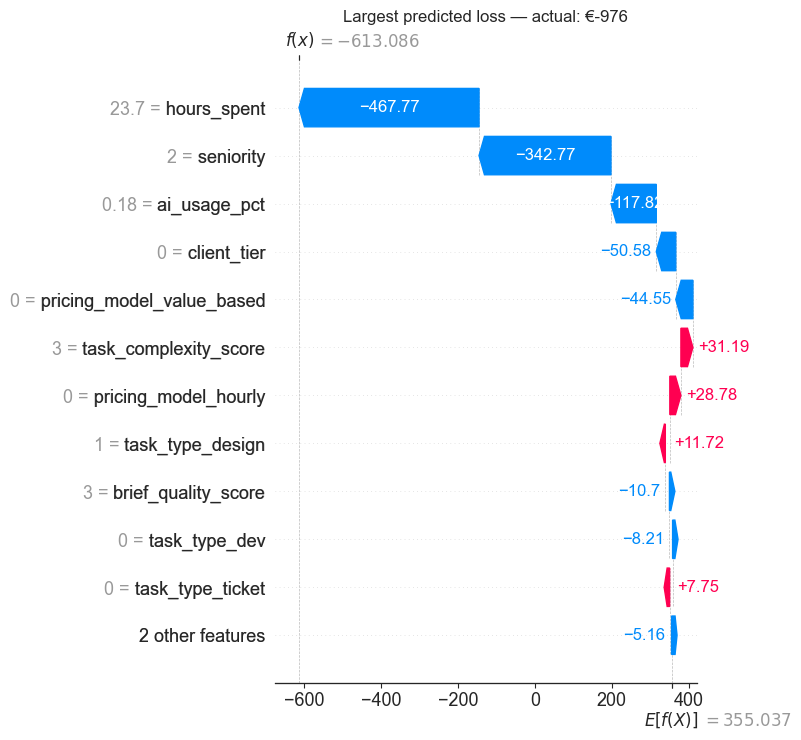

In [61]:
worst_idx = int(np.argmin(rf_reg.predict(X_test)))

fig = plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_reg[worst_idx], max_display=12, show=False)
plt.title(
    f"Largest predicted loss \u2014 actual: \u20ac{y_reg_test_w.iloc[worst_idx]:.0f}",
    fontsize=12,
)
plt.tight_layout()
plt.show()

The pattern recurs across the worst predicted losses: a senior contributor logging many
hours on a low-complexity task with moderate AI usage under non-value-based pricing.
This looks a lot like a **resource allocation failure**. Routing expensive senior staff
to simple, slow-burning work at standard rates reliably destroys margin, and the
classifier picks it up as the dominant loss signature.

## 7. XGBoost: Robustness Check

We refit the same problem with XGBoost on the identical feature matrix. The check is
straightforward: if both models rank features the same way in SHAP, the structural
findings are model-agnostic rather than artefacts of one algorithm.

In [62]:
xgb_reg = XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1,
)
xgb_clf = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y_clf_train == 0).sum() / (y_clf_train == 1).sum(),
    random_state=42, n_jobs=-1, eval_metric="logloss",
)

xgb_reg.fit(X_train, y_reg_train_w)
xgb_clf.fit(X_train, y_clf_train)

xgb_reg_preds = xgb_reg.predict(X_test)
xgb_clf_proba = xgb_clf.predict_proba(X_test)[:, 1]
xgb_clf_preds = xgb_clf.predict(X_test)

print(f"              RF  XGBoost")
print(f"R²       {r2_score(y_reg_test_w, reg_preds):>8.3f} {r2_score(y_reg_test_w, xgb_reg_preds):>8.3f}")
print(f"MAE (€)  {mean_absolute_error(y_reg_test_w, reg_preds):>8.0f} {mean_absolute_error(y_reg_test_w, xgb_reg_preds):>8.0f}")
print(f"ROC-AUC  {roc_auc_score(y_clf_test, clf_proba):>8.3f} {roc_auc_score(y_clf_test, xgb_clf_proba):>8.3f}")
print()
print(classification_report(y_clf_test, xgb_clf_preds, target_names=["profitable", "loss"]))

              RF  XGBoost
R²          0.223    0.208
MAE (€)       375      375
ROC-AUC     0.754    0.749

              precision    recall  f1-score   support

  profitable       0.85      0.76      0.80       421
        loss       0.42      0.56      0.48       132

    accuracy                           0.71       553
   macro avg       0.63      0.66      0.64       553
weighted avg       0.75      0.71      0.72       553



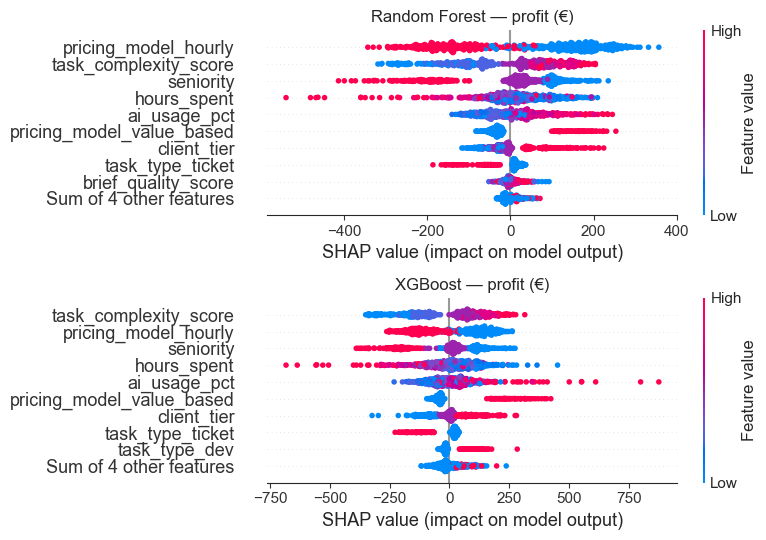

In [63]:
shap_xgb_reg = shap.TreeExplainer(xgb_reg)(X_test)

fig, axes = plt.subplots(2, 1, figsize=(16, 7))

plt.sca(axes[0])
shap.plots.beeswarm(shap_reg, max_display=10, show=False)
axes[0].set_title("Random Forest \u2014 profit (\u20ac)", fontsize=12)

plt.sca(axes[1])
shap.plots.beeswarm(shap_xgb_reg, max_display=10, show=False)
axes[1].set_title("XGBoost \u2014 profit (\u20ac)", fontsize=12)

plt.tight_layout()
plt.show()

RF and XGBoost agree on the substance. RF leads slightly in regression (R² ~0.22 vs
0.21) and in classification AUC; both fits are within sampling noise of each other. The
SHAP rankings agree on the top five drivers: `pricing_model_hourly`, seniority, task
complexity, client tier, and AI usage. The narrative does not depend on the algorithm.

## 8. Decision View: Where Losses Concentrate

The classification model (`is_loss = 1` when `profit < 0`) is the operational lens for the decision of where losses concentrate: it flags
which tasks are likely to lose money before they are staffed. The chart below
visualises the **empirical** loss rates that the classifier keys on, grouped by the top
SHAP drivers, so the model output reads as a business decision rather than a score.

For each top driver the test set is split into a "safe" bucket (green) and a "risky"
bucket (red): hourly vs fixed/value-based pricing, senior vs junior/mid, top-25%
hours, top-25% complexity, AI usage at or above the ~30% SHAP threshold, and high vs
low/mid client tier. Within each bucket we compute the share of tasks where
`is_loss = 1`. The result is a six-row table of low-rate, high-rate, gap, and
high-bucket exposure, plotted on a shared y-axis.

- **Left panel (dumbbell).** Two dots per row connected by a grey segment. Green is
  the loss rate at the safe level, red at the risky level. The segment length is the
  gap: longer means the feature flips outcomes more strongly. The dotted vertical
  line is the overall test-set loss rate (~24%) as a no-information baseline.
- **Direction.** Red to the right of green means the high level increases loss risk
  (hourly, long hours, senior). Red to the left means it is protective (AI usage,
  complexity, client tier).
- **Right panel (exposure).** The bar is the share of tasks in the risky bucket. A
  gap only matters if many tasks are exposed to it.

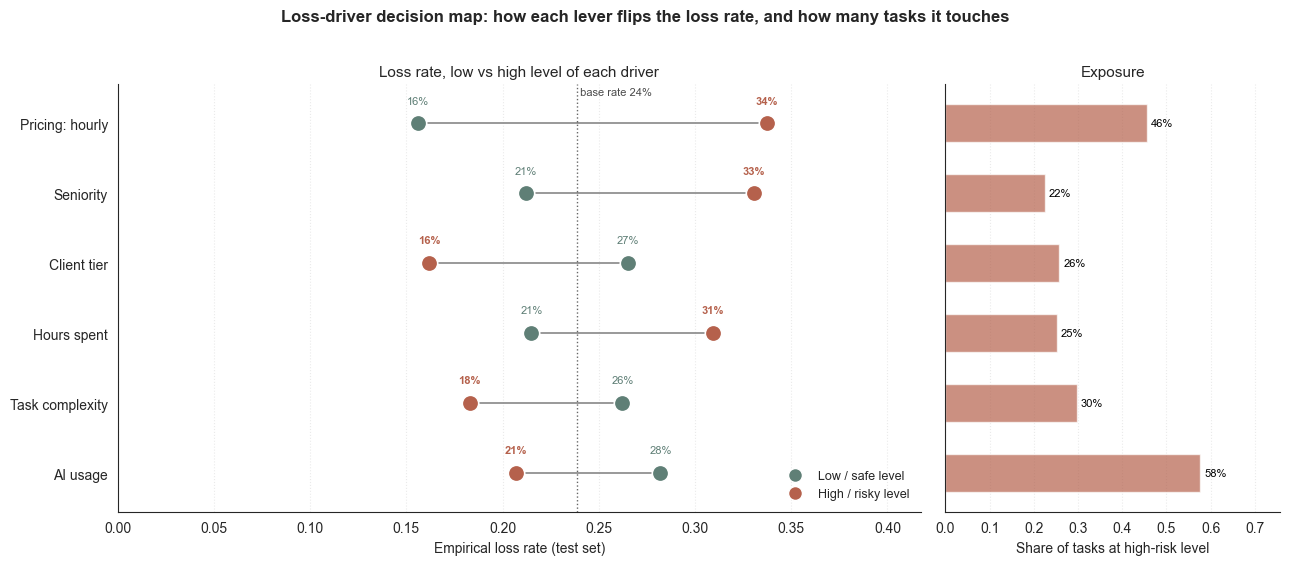

              feature low_rate high_rate  gap high_share
         ai_usage_pct      28%       21%  -8%        58%
task_complexity_score      26%       18%  -8%        30%
          hours_spent      21%       31%   9%        25%
          client_tier      27%       16% -10%        26%
            seniority      21%       33%  12%        22%
 pricing_model_hourly      16%       34%  18%        46%


In [64]:
clf_feats = ["pricing_model_hourly", "seniority", "hours_spent", "ai_usage_pct",
             "task_complexity_score", "client_tier"]
LABELS = {
    "pricing_model_hourly":  ("Pricing: hourly",      "fixed/value", "hourly"),
    "seniority":             ("Seniority",            "junior/mid",  "senior"),
    "hours_spent":           ("Hours spent",          "short",       "long (top 25%)"),
    "ai_usage_pct":          ("AI usage",             f"below {threshold:.0%}", f"at or above {threshold:.0%}"),
    "task_complexity_score": ("Task complexity",      "low/mid",     "high (top 25%)"),
    "client_tier":           ("Client tier",          "low/mid",     "high"),
}

def split_mask(col, X):
    s = X[col]
    if col == "ai_usage_pct":
        return s >= threshold
    if col in {"hours_spent", "task_complexity_score"}:
        return s >= s.quantile(0.75)
    if col == "seniority":
        return s >= 2  # senior
    if col == "client_tier":
        return s >= 2  # high
    return s >= 1      # binary one-hot

base_rate = y_clf_test.mean()
rows = []
for col in clf_feats:
    high = split_mask(col, X_test)
    low  = ~high
    rows.append({
        "feature": col,
        "low_rate":   y_clf_test[low].mean(),
        "high_rate":  y_clf_test[high].mean(),
        "low_share":  low.mean(),
        "high_share": high.mean(),
        "gap":        y_clf_test[high].mean() - y_clf_test[low].mean(),
    })
loss_df = pd.DataFrame(rows).sort_values("gap", key=abs, ascending=True)

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(13, 5.5),
    gridspec_kw={"width_ratios": [2.4, 1]}, sharey=True,
)

y_pos = np.arange(len(loss_df))
for i, (_, r) in enumerate(loss_df.iterrows()):
    ax1.plot([r.low_rate, r.high_rate], [i, i],
             color="#888", linewidth=1.2, zorder=1)
    ax1.scatter(r.low_rate,  i, s=140, color=ACCENT, zorder=3,
                edgecolor="white", linewidth=1.2)
    ax1.scatter(r.high_rate, i, s=140, color=RISK,   zorder=3,
                edgecolor="white", linewidth=1.2)
    ax1.text(r.low_rate,  i + 0.28, f"{r.low_rate:.0%}",  ha="center",
             fontsize=8, color=ACCENT)
    ax1.text(r.high_rate, i + 0.28, f"{r.high_rate:.0%}", ha="center",
             fontsize=8, color=RISK, fontweight="bold")

ax1.axvline(base_rate, color="black", linestyle=":", linewidth=1, alpha=0.6)
ax1.text(base_rate, len(loss_df) - 0.6, f" base rate {base_rate:.0%}",
         fontsize=8, color="black", alpha=0.7)
ax1.set_yticks(y_pos)
ax1.set_yticklabels([LABELS[f][0] for f in loss_df.feature], fontsize=10)
ax1.set_xlim(0, max(loss_df.high_rate.max(), loss_df.low_rate.max()) + 0.08)
ax1.set_xlabel("Empirical loss rate (test set)")
ax1.set_title("Loss rate, low vs high level of each driver", fontsize=11)
ax1.grid(axis="x", linestyle=":", alpha=0.4)

ax2.barh(y_pos, loss_df["high_share"], color=RISK, alpha=0.7, height=0.55)
for i, (_, r) in enumerate(loss_df.iterrows()):
    ax2.text(r.high_share + 0.01, i, f"{r.high_share:.0%}",
             va="center", fontsize=8, color="black")
ax2.set_xlim(0, max(loss_df.high_share) + 0.18)
ax2.set_xlabel("Share of tasks at high-risk level")
ax2.set_title("Exposure", fontsize=11)
ax2.grid(axis="x", linestyle=":", alpha=0.4)

from matplotlib.lines import Line2D
legend = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=ACCENT,
           markersize=10, label="Low / safe level"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=RISK,
           markersize=10, label="High / risky level"),
]
ax1.legend(handles=legend, loc="lower right", frameon=False, fontsize=9)

fig.suptitle(
    "Loss-driver decision map: how each lever flips the loss rate, and how many tasks it touches",
    fontsize=12, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

print(loss_df[["feature", "low_rate", "high_rate", "gap", "high_share"]]
      .assign(**{c: lambda d, c=c: d[c].map(lambda v: f"{v:.0%}")
                 for c in ["low_rate", "high_rate", "gap", "high_share"]})
      .to_string(index=False))

## 9. Conclusions


AI compresses hours. Whether that compression becomes margin or leaks to the client is
decided by the contract, not by AI itself. Under fixed and value-based pricing the
saved hours stay with the firm; under hourly pricing they are returned as fewer billed
hours. The OLS interaction (-701 euros, p < 0.001) and the SHAP dependence plots agree:
on hourly tasks AI's contribution is negative at every usage level. Quality is not an
independent channel. Rework matters only through the hours it consumes, and its
financial impact is fully absorbed once `hours_spent` is in the model.

### 9.2 The classification view

The regression sizes the effect; the classifier locates the decision. With balanced
class weights and the pruned feature matrix, the classifier reaches ROC-AUC ~0.75 and
loss recall above 0.55, more than doubling the recall of an unbalanced fit. That makes
it usable as a routing tool: flag a task before it is staffed and the contract or the
assignment can still be changed.

The decision map above ranks drivers by how strongly they flip the empirical loss rate
and by how many tasks they touch. The hierarchy reads as follows:

1. **Pricing model is the largest single lever.** Hourly tasks lose money 34% of the
   time against 16% on fixed and value-based work, an 18-point gap. Hourly is also the
   most prevalent risk bucket (46% of tasks), which makes it the highest-leverage policy
   change.
2. **Seniority is the staffing lever.** Senior contributors raise loss probability from
   21% to 33% (+12 points) when the task is not complex enough to justify their cost.
   Pairing senior staff with low complexity at standard rates is the modal loss
   pattern in the SHAP waterfalls.
3. **Hours and complexity are diagnostic flags.** Long hours push the loss rate up by
   9 points; high complexity pushes it down by 8. The combination of long hours plus
   low complexity is the operational fingerprint of a loss, and the classifier weights
   it heavily.
4. **AI usage is a second-order modifier.** Below the ~30% threshold the loss rate is
   28%; at or above it the rate drops to 19% (-9 points). The protection is real but
   conditional on contracts that let the firm keep the saved hours.

### 9.3 Decision: what to change first

From the classification view three
operational levers stand out, in order of expected return:

- **Renegotiate or retire the hourly model on AI-heavy work.** The contract structure
  converts efficiency gains into client discounts. Even a partial shift to outcome-
  linked or fixed pricing on high-AI workstreams captures the savings the firm is
  currently giving away.
- **Re-route senior staff to high-complexity tasks.** Senior plus low complexity is
  the single most reliable loss signature. Either match seniority to complexity or
  charge a premium that covers the cost.
- **Set an AI adoption floor on fixed and value-based work.** Below ~30% AI usage the
  net effect is a drag because of overhead. Either commit to deeper integration or
  skip AI on that task.

### 9.4 What the data is missing

The four diagnostic questions have answers, but the ceiling on R² (0.21 to 0.22 across
RF and XGBoost) is structural. Three additions would lift it materially:

- The **negotiated rate** for the task. Pricing model is a category; the actual euro
  rate is what determines margin and is unobserved.
- The **loaded cost** of the contributor. Seniority is a three-level proxy; salaries
  and overhead vary continuously inside each level.
- A **client-retention flag**. The strategic value of a task is partly whether the
  client returns; without that signal, single-task profit understates the long horizon.

Tracking **AI tool quality** (which model, which workflow) and aggregating to the
project level would also help, since pricing is negotiated per project, not per task.

### 9.5 Robustness

Findings replicate across OLS, LASSO, Ridge, Random Forest, and XGBoost. Top features
and signs are stable. The two interactions that matter (AI x hourly, AI x seniority)
are significant under HC3 and visible in the tree-based SHAP. The narrative is not
algorithm-specific.